# Chapter 3.3 EB Baselines, Ablations, and Claim Audit

This split starts from the EB main model cache written by Chapter 3.2. It preserves the retired monolith coverage for solver comparison, CNF endpoint baseline, time sampling, capacity, straightness, paper table export, artifact index, and summary/audit outputs.

Retired monolith map: Sections 8-14 of `archive/notebooks_retired_20260604_ch03_split/03_flow_matching_from_scratch.ipynb` now live here. The toy and main EB training artifacts remain owned by `03_1` and `03_2`; this notebook owns the baseline, ablation, diagnostic, paper-table, index, summary, and manifest artifacts listed in the final audit.


## Tutorial setup

The setup cells keep reusable infrastructure here: project-root discovery, deterministic seeds, output directories, and save/display helpers. Scientific questions, configurations, model runs, metric tables, figures, and claim boundaries are introduced inside each experiment section.


In [1]:
from pathlib import Path
import json
import os
import random
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

try:
    import torch
except ImportError as exc:
    raise ImportError("This notebook requires PyTorch for CFM training and sampling.") from exc

CWD = Path.cwd().resolve()
root_candidates = [
    CWD,
    CWD.parent,
    CWD.parent.parent,
    CWD / "flow_matching_for_dynamic_biology",
    CWD.parent / "flow_matching_for_dynamic_biology",
    CWD.parent.parent / "flow_matching_for_dynamic_biology",
]
for candidate in root_candidates:
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate project root containing src/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import ch03_tutorial as ch03
from src.utils import set_seed
from src.data import load_eb_timecourse_for_ch03, copy_trajectorynet_eb_to_data
from src.models import VelocityMLP, count_parameters
from src.losses import cfm_batch, cfm_loss_from_pairs
from src.train import train_cfm_steps
from src.sampling import euler_sample, midpoint_sample, odeint_sample
from src.metrics import endpoint_metrics, mmd_rbf, sliced_wasserstein_distance, trajectory_straightness
from src.plots import plot_nfe_vs_error


In [2]:
SEED = int(os.environ.get("CH03_SEED", "42"))
set_seed(SEED)
rng = np.random.default_rng(SEED)

QUICK_MODE = os.environ.get("CH03_QUICK", "1") == "1"
SMOKE_MODE = os.environ.get("CH03_SMOKE_MODE", "0") == "1"
PAPER_FIGURE_MODE = os.environ.get("CH03_PAPER_FIGURE_MODE", "1") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FULL_RUN_HINTS = {
    "eb_train_steps": 10000,
    "cnf_steps": 600,
    "time_ablation_steps": 1200,
    "capacity_steps": 1200,
    "notes": "Set CH03_QUICK=0 for full-run settings; default remains quick and reproducible.",
}

context = ch03.make_ch03_context(PROJECT_ROOT)
FIG_DIR = context.fig_dir
TABLE_DIR = context.table_dir
OUT_DIR = context.output_dir
PAPER_COLORS = ch03.PAPER_COLORS

tracker = ch03.Ch03ArtifactTracker(context, paper_figure_mode=PAPER_FIGURE_MODE)
skipped_items = []

set_paper_style = ch03.set_paper_style
add_panel_label = ch03.add_panel_label
short_strategy_label = ch03.short_strategy_label
clean_spines = ch03.clean_spines
format_metric_axis = ch03.format_metric_axis
add_note = ch03.add_note
as_np = ch03.as_np
subsample_idx = ch03.subsample_idx
robust_limits = ch03.robust_limits
format_axis = ch03.format_axis

set_paper_style()
print({"project_root": str(PROJECT_ROOT), "device": DEVICE, "quick_mode": QUICK_MODE, "smoke_mode": SMOKE_MODE, "seed": SEED})


{'project_root': '/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology', 'device': 'cuda', 'quick_mode': True, 'smoke_mode': False, 'seed': 42}


In [3]:
# Artifact save/display helpers live in src.ch03_tutorial.Ch03ArtifactTracker.


In [4]:
# Figure and table serialization is handled through tracker.* methods.


## 1. Load EB inputs and the main-model cache

The baseline and ablation cells need the same EB split and PHATE projector as the main notebook. They load the saved main model instead of re-running the main training loop. If the cache is missing, run `03_2_eb20d_main_flow_matching.ipynb` first.


In [5]:
EB_PATH = PROJECT_ROOT / "data" / "trajectorynet_eb" / "eb_velocity_v5.npz"
EB_SOURCE_PATH = PROJECT_ROOT.parent / "baselines" / "trajectorynet" / "data" / "eb_velocity_v5.npz"
if not EB_PATH.exists() and EB_SOURCE_PATH.exists():
    copy_trajectorynet_eb_to_data(EB_SOURCE_PATH, EB_PATH)

eb = load_eb_timecourse_for_ch03(EB_PATH, max_cells_per_time=900 if QUICK_MODE else None, seed=SEED)
cost_embedding = "X_cost"
plot_embedding = "X_plot"
n_cost_dims = int(eb[cost_embedding].shape[1])

time_counts = pd.Series(eb["time"].astype(str)).value_counts().sort_index()
time_order = list(time_counts.index)
source_time = time_order[0]
target_time = time_order[1]
mask_source = eb["time"].astype(str) == source_time
mask_target = eb["time"].astype(str) == target_time
X_source_20d = np.asarray(eb["X_cost"][mask_source], dtype=np.float32)
X_target_20d = np.asarray(eb["X_cost"][mask_target], dtype=np.float32)
X_source_phate = np.asarray(eb["X_plot"][mask_source], dtype=np.float32)
X_target_phate = np.asarray(eb["X_plot"][mask_target], dtype=np.float32)
count_preview = pd.DataFrame({"time": time_counts.index, "n_cells": time_counts.values})
tracker.display_table(count_preview, n=8)


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


,time,n_cells
0,0,900
1,1,900
2,2,900
3,3,900
4,4,900


In [6]:
src_train_idx, src_val_idx = ch03.train_val_indices(len(X_source_20d), seed=SEED + 11)
tgt_train_idx, tgt_val_idx = ch03.train_val_indices(len(X_target_20d), seed=SEED + 12)
X0_train, X0_val = X_source_20d[src_train_idx], X_source_20d[src_val_idx]
X1_train, X1_val = X_target_20d[tgt_train_idx], X_target_20d[tgt_val_idx]
X0_train_phate, X0_val_phate = X_source_phate[src_train_idx], X_source_phate[src_val_idx]
X1_train_phate, X1_val_phate = X_target_phate[tgt_train_idx], X_target_phate[tgt_val_idx]

pair_batch_fn = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 13)

val_pair_n = 1200 if QUICK_MODE else 2500
if SMOKE_MODE:
    val_pair_n = 180
val_pair_rng = np.random.default_rng(SEED + 13)
val_i0 = val_pair_rng.integers(0, len(X0_val), size=int(val_pair_n))
val_i1 = val_pair_rng.integers(0, len(X1_val), size=int(val_pair_n))
val_x0 = X0_val[val_i0].astype(np.float32)
val_x1 = X1_val[val_i1].astype(np.float32)
val_t_grid = np.asarray([0.25, 0.50, 0.75], dtype=np.float32)
print({"X0_train": X0_train.shape, "X1_train": X1_train.shape, "X0_val": X0_val.shape, "X1_val": X1_val.shape})


{'X0_train': (720, 20), 'X1_train': (720, 20), 'X0_val': (180, 20), 'X1_val': (180, 20)}


In [7]:
# Validation CFM MSE is implemented in src.ch03_tutorial.val_cfm_mse.


In [8]:
MAIN_MODEL_PATH = OUT_DIR / f"ch03_eb20d_velocity_mlp_seed{SEED}.pt"
MAIN_CONFIG_PATH = OUT_DIR / f"ch03_eb20d_main_config_seed{SEED}.json"
if not MAIN_MODEL_PATH.exists() or not MAIN_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Missing EB main model cache. Run notebooks/03_2_eb20d_main_flow_matching.ipynb before this baseline notebook."
    )
main_model_config = json.loads(MAIN_CONFIG_PATH.read_text())
eb_model = VelocityMLP(
    x_dim=int(main_model_config.get("x_dim", 20)),
    hidden_dim=int(main_model_config.get("hidden_dim", 256)),
    hidden_layers=int(main_model_config.get("hidden_layers", 4)),
).to(DEVICE)
eb_model.load_state_dict(torch.load(MAIN_MODEL_PATH, map_location=DEVICE))
eb_model.eval()
print({"loaded_model_cache": str(MAIN_MODEL_PATH.relative_to(PROJECT_ROOT)), "main_steps": main_model_config.get("steps")})


{'loaded_model_cache': 'outputs/ch03/ch03_eb20d_velocity_mlp_seed42.pt', 'main_steps': 1500}


/tmp/ipykernel_509528/3295107250.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eb_model.load_state_dict(torch.load(MAIN_MODEL_PATH, map_location=DEVICE))


In [9]:
from sklearn.neighbors import KNeighborsRegressor

knn_neighbors = min(20, len(eb["X_cost"]))
phate_projector = KNeighborsRegressor(n_neighbors=knn_neighbors, weights="distance")
phate_projector.fit(np.asarray(eb["X_cost"], dtype=np.float32), np.asarray(eb["X_plot"], dtype=np.float32))

sample_n = min(1200 if QUICK_MODE else 2200, len(X0_val))
if SMOKE_MODE:
    sample_n = min(150, len(X0_val))
sample_idx = subsample_idx(len(X0_val), sample_n, seed=SEED + 31)
x0_eval_20d = torch.as_tensor(X0_val[sample_idx], dtype=torch.float32, device=DEVICE)
target_eval_20d = X1_val.astype(np.float32)
print({"eval_source_cells": int(sample_n), "target_eval_cells": int(len(target_eval_20d)), "projection": "kNN X_cost to X_plot for display only"})


{'eval_source_cells': 180, 'target_eval_cells': 180, 'projection': 'kNN X_cost to X_plot for display only'}


## Shared ablation evaluation helpers

These helpers keep repeated endpoint-metric and seeded-pair mechanics short while leaving the model definitions, training loops, and metric construction visible in the experiment cells.


In [10]:
metric_n_projections = 48 if SMOKE_MODE else 128


In [11]:
# Endpoint ODE wrappers live in src.ch03_tutorial.EndpointODEFunc.


## 8. Solver Comparison Lite

### Question
How much do numerical integration choices change endpoint metrics after the EB 20D CFM vector field has already been trained?

This is a post-training sampling diagnostic, not a CNF training baseline.


### Configuration table

The configuration fixes the model and held-out EB target set, then varies only the sampler and numerical budget.


In [12]:
solver_specs = [("euler", K) for K in [5, 10, 20, 50, 100]] + [("midpoint", K) for K in [5, 10, 20, 50]]
if SMOKE_MODE:
    solver_specs = [("euler", K) for K in [5, 10]] + [("midpoint", K) for K in [5, 10]]

rtols = [1e-3, 1e-5]
if SMOKE_MODE:
    rtols = [1e-3]

solver_config = pd.DataFrame(
    [{"sampler": name, "steps": steps, "rtol": np.nan, "model": "cached EB CFM"} for name, steps in solver_specs]
    + [{"sampler": "dopri5", "steps": "adaptive", "rtol": rtol, "model": "cached EB CFM"} for rtol in rtols]
)
tracker.display_table(solver_config, n=12)


,sampler,steps,rtol,model
0,euler,5,NaN,cached EB CFM
1,euler,10,NaN,cached EB CFM
2,euler,20,NaN,cached EB CFM
3,euler,50,NaN,cached EB CFM
4,euler,100,NaN,cached EB CFM
5,midpoint,5,NaN,cached EB CFM
6,midpoint,10,NaN,cached EB CFM
7,midpoint,20,NaN,cached EB CFM
8,midpoint,50,NaN,cached EB CFM
9,dopri5,adaptive,0.00100,cached EB CFM


,sampler,steps,rtol,model
0,euler,5,NaN,cached EB CFM
1,euler,10,NaN,cached EB CFM
2,euler,20,NaN,cached EB CFM
3,euler,50,NaN,cached EB CFM
4,euler,100,NaN,cached EB CFM
5,midpoint,5,NaN,cached EB CFM
6,midpoint,10,NaN,cached EB CFM
7,midpoint,20,NaN,cached EB CFM
8,midpoint,50,NaN,cached EB CFM
9,dopri5,adaptive,0.00100,cached EB CFM


### Run

Each row below samples from the same source cells, evaluates endpoint discrepancy in 20D PC space, and records the sampler's NFE and wall-clock time.


In [13]:
solver_rows = []
for solver_name, K in solver_specs:
    tic = time.perf_counter()
    if solver_name == "euler":
        endpoint_t, traj_t, nfe = euler_sample(eb_model, x0_eval_20d, n_steps=K, return_traj=True)
    elif solver_name == "midpoint":
        endpoint_t, traj_t, nfe = midpoint_sample(eb_model, x0_eval_20d, n_steps=K, return_traj=True)
    else:
        raise ValueError(solver_name)
    wall = time.perf_counter() - tic
    endpoint_20d = as_np(endpoint_t)
    traj_20d = as_np(traj_t)
    solver_rows.append({
        "sampler": solver_name,
        "steps": int(K),
        "rtol": np.nan,
        "nfe": int(nfe),
        "wall_time_sec": float(wall),
        "mmd_20d": float(mmd_rbf(endpoint_20d, target_eval_20d)),
        "sliced_w2_20d": float(sliced_wasserstein_distance(endpoint_20d, target_eval_20d, n_projections=128 if not SMOKE_MODE else 48, seed=SEED + K + (0 if solver_name == "euler" else 1000))),
        "trajectory_straightness_20d": float(trajectory_straightness(traj_20d)),
    })


In [14]:
for rtol in rtols:
    try:
        tic = time.perf_counter()
        endpoint_t, traj_t, nfe = odeint_sample(eb_model, x0_eval_20d, rtol=rtol, atol=rtol, method="dopri5")
        wall = time.perf_counter() - tic
        endpoint_20d = as_np(endpoint_t)
        traj_20d = as_np(traj_t)
        solver_rows.append({
            "sampler": "dopri5",
            "steps": "adaptive",
            "rtol": float(rtol),
            "nfe": int(nfe),
            "wall_time_sec": float(wall),
            "mmd_20d": float(mmd_rbf(endpoint_20d, target_eval_20d)),
            "sliced_w2_20d": float(sliced_wasserstein_distance(endpoint_20d, target_eval_20d, n_projections=128 if not SMOKE_MODE else 48, seed=SEED + int(-np.log10(rtol)))),
            "trajectory_straightness_20d": float(trajectory_straightness(traj_20d)),
        })
    except ImportError as exc:
        message = f"torchdiffeq unavailable; skipped dopri5 rtol={rtol}: {exc}"
        warnings.warn(message)
        skipped_items.append(message)
    except Exception as exc:
        message = f"dopri5 failed for rtol={rtol}: {type(exc).__name__}: {exc}"
        warnings.warn(message)
        skipped_items.append(message)

solver_table = pd.DataFrame(solver_rows)
tracker.save_csv(solver_table, "table03_01_solver_diagnostics.csv")
solver_table


,sampler,steps,rtol,nfe,wall_time_sec,mmd_20d,sliced_w2_20d,trajectory_straightness_20d
0,euler,5,NaN,5,0.082673,0.018927,0.624751,0.069437
1,euler,10,NaN,10,0.002325,0.015407,0.577044,0.068417
2,euler,20,NaN,20,0.004448,0.014327,0.529454,0.066997
3,euler,50,NaN,50,0.009302,0.013855,0.551289,0.065891
4,euler,100,NaN,100,0.018688,0.013725,0.515430,0.065483
5,midpoint,5,NaN,10,0.002413,0.013720,0.537626,0.064010
6,midpoint,10,NaN,20,0.003923,0.013639,0.511072,0.064796
7,midpoint,20,NaN,40,0.007298,0.013615,0.539987,0.064992
8,midpoint,50,NaN,100,0.017270,0.013608,0.537164,0.065046
9,dopri5,adaptive,0.00100,26,2.968296,0.013593,0.547940,0.000000


### Metrics table

Lower endpoint MMD and Sliced W2 indicate closer generated endpoint distributions in the 20D training space.


In [15]:
tracker.display_table(pd.read_csv(TABLE_DIR / "table03_01_solver_diagnostics.csv"), n=10)


,sampler,steps,rtol,nfe,wall_time_sec,mmd_20d,sliced_w2_20d,trajectory_straightness_20d
0,euler,5,NaN,5,0.082673,0.018927,0.624751,0.069437
1,euler,10,NaN,10,0.002325,0.015407,0.577044,0.068417
2,euler,20,NaN,20,0.004448,0.014327,0.529454,0.066997
3,euler,50,NaN,50,0.009302,0.013855,0.551289,0.065891
4,euler,100,NaN,100,0.018688,0.013725,0.515430,0.065483
5,midpoint,5,NaN,10,0.002413,0.013720,0.537626,0.064010
6,midpoint,10,NaN,20,0.003923,0.013639,0.511072,0.064796
7,midpoint,20,NaN,40,0.007298,0.013615,0.539987,0.064992
8,midpoint,50,NaN,100,0.017270,0.013608,0.537164,0.065046
9,dopri5,adaptive,0.001,26,2.968296,0.013593,0.547940,0.000000


,sampler,steps,rtol,nfe,wall_time_sec,mmd_20d,sliced_w2_20d,trajectory_straightness_20d
0,euler,5,NaN,5,0.082673,0.018927,0.624751,0.069437
1,euler,10,NaN,10,0.002325,0.015407,0.577044,0.068417
2,euler,20,NaN,20,0.004448,0.014327,0.529454,0.066997
3,euler,50,NaN,50,0.009302,0.013855,0.551289,0.065891
4,euler,100,NaN,100,0.018688,0.013725,0.515430,0.065483
5,midpoint,5,NaN,10,0.002413,0.013720,0.537626,0.064010
6,midpoint,10,NaN,20,0.003923,0.013639,0.511072,0.064796
7,midpoint,20,NaN,40,0.007298,0.013615,0.539987,0.064992
8,midpoint,50,NaN,100,0.017270,0.013608,0.537164,0.065046
9,dopri5,adaptive,0.001,26,2.968296,0.013593,0.547940,0.000000


### Figure

The saved figure keeps the same artifact name as the retired monolith and is displayed immediately after saving.


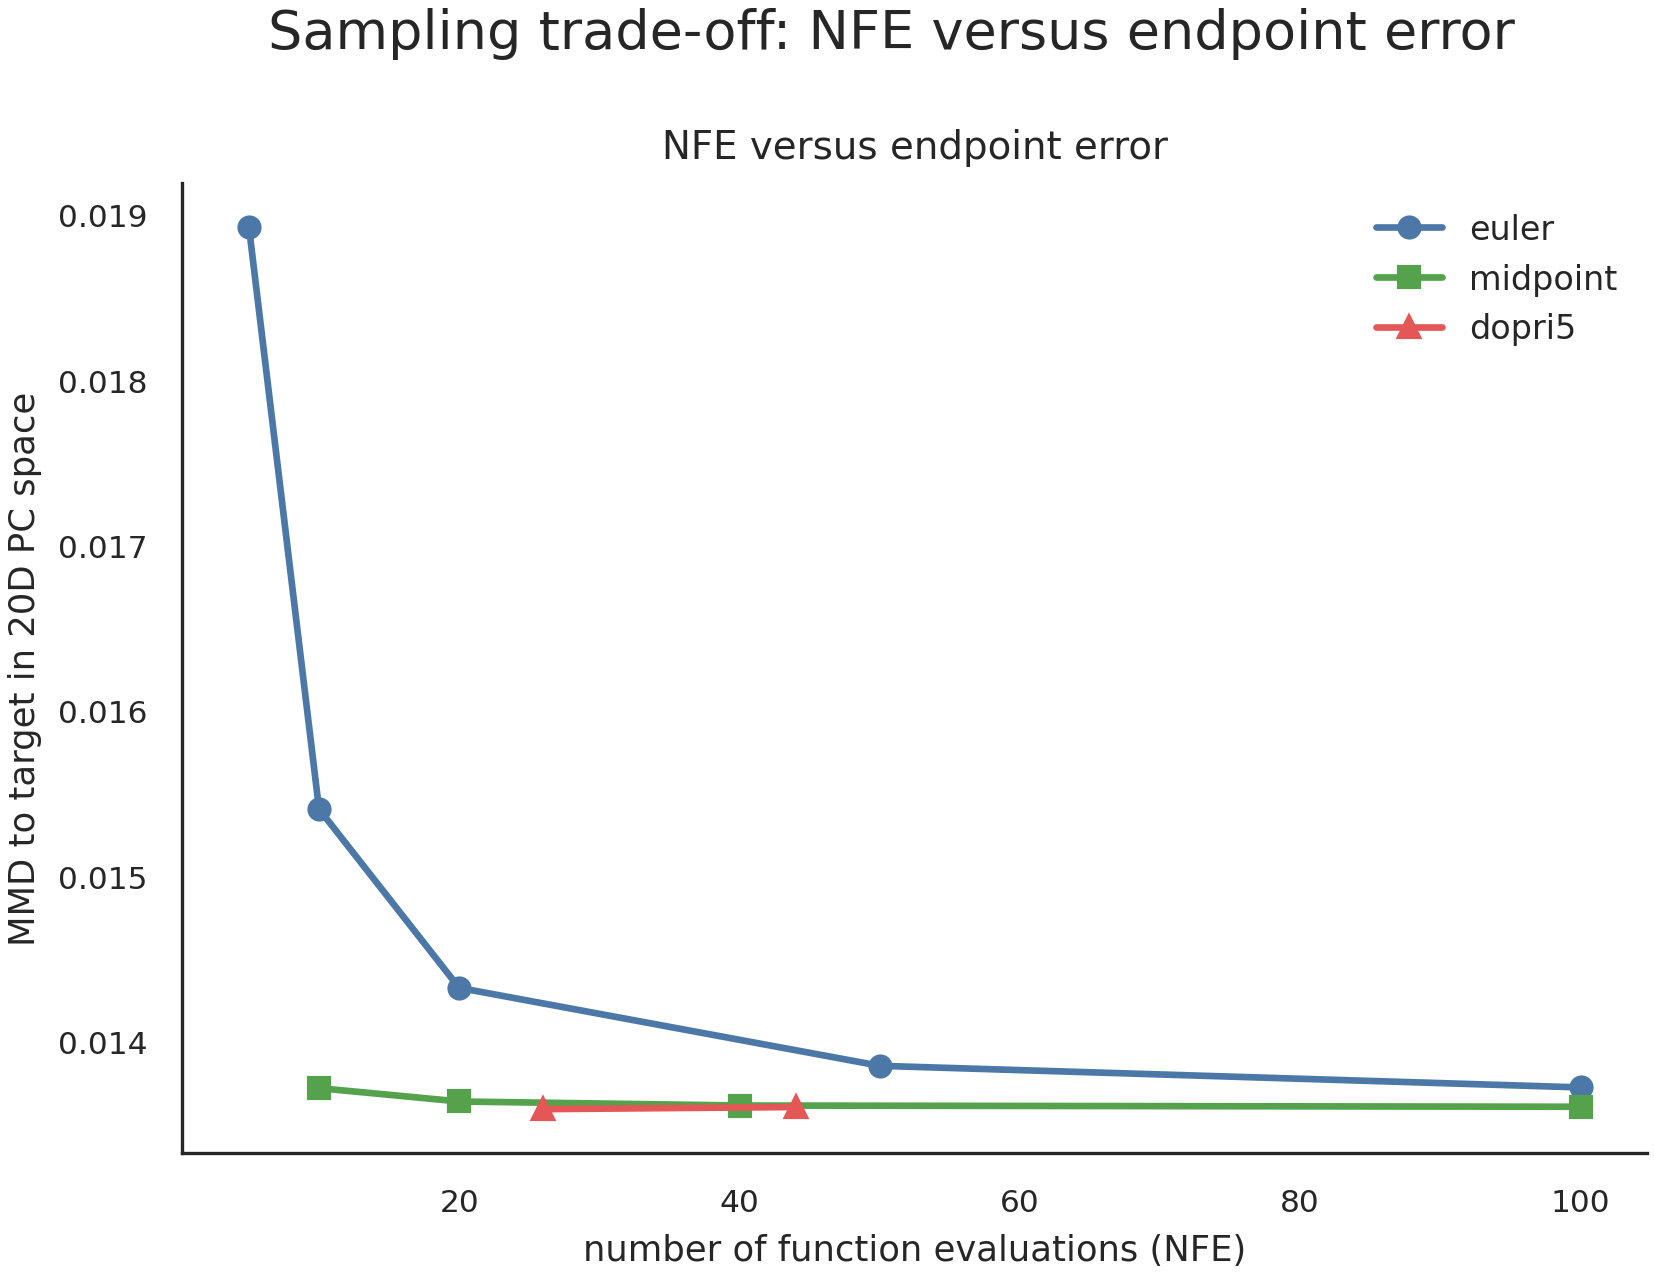

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/fig03_10_nfe_vs_endpoint_error.png')

In [16]:
fig, ax = plot_nfe_vs_error(solver_table, y="mmd_20d")
ax.set_ylabel("MMD to target in 20D PC space")
ax.set_title("NFE versus endpoint error")
fig03_10_path = tracker.save_figure(fig, "fig03_10_nfe_vs_endpoint_error.png")
tracker.display_saved_figure(fig03_10_path, width=650)


### Claim boundary

This section supports a numerical-solver diagnostic for a fixed trained CFM field. It does not claim that adaptive ODE sampling is a trained CNF baseline, and it does not use PHATE coordinates for metrics.


## 9. CNF-Endpoint Baseline: Same Endpoint Objective, ODE-in-the-Loop Training

### Question
What changes when the endpoint-pair objective is optimized through an ODE solve instead of CFM's local velocity-regression objective?

The comparison isolates training control flow and endpoint behavior. It is not FFJORD or likelihood training.


### Configuration table

Both methods use the same EB 20D train/validation split and endpoint-pair source. QUICK and SMOKE modes keep the inherited semantics from the retired monolith.


In [17]:
cnf_endpoint_completed = False
cnf_endpoint_skipped_reason = None
cnf_steps = 80 if QUICK_MODE else 600
cnf_batch_size = 64 if QUICK_MODE else 128
cnf_rtol = 1e-3 if QUICK_MODE else 1e-4
cnf_log_every = 20 if QUICK_MODE else 50
cfm_e1_sample_steps = 30 if QUICK_MODE else 50

if SMOKE_MODE:
    cnf_steps = 6
    cnf_batch_size = 32
    cnf_rtol = 2e-3
    cnf_log_every = 3
    cfm_e1_sample_steps = 8

cnf_eval_n = min(360 if QUICK_MODE else 900, len(X0_val), len(X1_val))
if SMOKE_MODE:
    cnf_eval_n = min(90, len(X0_val), len(X1_val))

eval_idx0 = subsample_idx(len(X0_val), cnf_eval_n, seed=SEED + 200)
eval_target_idx = subsample_idx(len(X1_val), cnf_eval_n, seed=SEED + 201)
e1_eval_x0_20d = X0_val[eval_idx0].astype(np.float32)
e1_eval_target_20d = X1_val[eval_target_idx].astype(np.float32)

E1_config = pd.DataFrame([
    {"method": "CFM", "objective": "local velocity regression", "uses_ode_in_training": False, "steps": cnf_steps, "batch_size": cnf_batch_size, "sample_steps_or_rtol": cfm_e1_sample_steps},
    {"method": "CNF-Endpoint", "objective": "endpoint MSE after ODE solve", "uses_ode_in_training": True, "steps": cnf_steps, "batch_size": cnf_batch_size, "sample_steps_or_rtol": cnf_rtol},
])
tracker.display_table(E1_config, n=8)


,method,objective,uses_ode_in_training,steps,batch_size,sample_steps_or_rtol
0,CFM,local velocity regression,False,80,64,30.000
1,CNF-Endpoint,endpoint MSE after ODE solve,True,80,64,0.001


,method,objective,uses_ode_in_training,steps,batch_size,sample_steps_or_rtol
0,CFM,local velocity regression,False,80,64,30.000
1,CNF-Endpoint,endpoint MSE after ODE solve,True,80,64,0.001


### Run

The run first trains a lightweight CFM probe for a fair training-cost curve, then attempts the adjoint CNF endpoint run when `torchdiffeq` is available.


In [18]:
set_seed(SEED + 210)
cfm_e1_model = VelocityMLP(x_dim=20, hidden_dim=256, hidden_layers=4).to(DEVICE)
cfm_e1_optimizer = torch.optim.Adam(cfm_e1_model.parameters(), lr=1e-3)
cfm_e1_pair_batch = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 211)
cfm_e1_rows = []
start = time.perf_counter()
last_time = start
last_step = 0
for step in range(1, cnf_steps + 1):
    batch = cfm_e1_pair_batch(cnf_batch_size)
    x0 = torch.as_tensor(batch["x0"], dtype=torch.float32, device=DEVICE)
    x1 = torch.as_tensor(batch["x1"], dtype=torch.float32, device=DEVICE)
    loss = cfm_loss_from_pairs(cfm_e1_model, x0, x1)
    cfm_e1_optimizer.zero_grad()
    loss.backward()
    cfm_e1_optimizer.step()
    if step == 1 or step % cnf_log_every == 0 or step == cnf_steps:
        now = time.perf_counter()
        _, sample_nfe, met = ch03.eval_cfm_endpoint_20d(cfm_e1_model, e1_eval_x0_20d, e1_eval_target_20d, n_steps=cfm_e1_sample_steps, seed=SEED + step, device=DEVICE, n_projections=metric_n_projections)
        cfm_e1_rows.append({
            "method": "CFM",
            "step": int(step),
            "wall_time_sec": float(now - start),
            "sec_per_step": float((now - last_time) / max(1, step - last_step)),
            "final_train_loss_20d": float(loss.detach().cpu()),
            "val_endpoint_mmd_20d": met["endpoint_mmd_20d"],
            "val_sliced_w2_20d": met["sliced_w2_20d"],
            "train_nfe_per_step": 1,
            "sample_nfe": int(sample_nfe),
        })
        last_time = now
        last_step = step

cnf_rows = []
cnf_model = None


In [19]:
try:
    from torchdiffeq import odeint_adjoint

    set_seed(SEED + 220)
    cnf_model = VelocityMLP(x_dim=20, hidden_dim=256, hidden_layers=4).to(DEVICE)
    cnf_optimizer = torch.optim.Adam(cnf_model.parameters(), lr=1e-3)
    cnf_pair_batch = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 211)
    ode_func = ch03.EndpointODEFunc(cnf_model)
    t_grid_train = torch.tensor([0.0, 1.0], dtype=torch.float32, device=DEVICE)
    start = time.perf_counter()
    last_time = start
    last_step = 0
    for step in range(1, cnf_steps + 1):
        batch = cnf_pair_batch(cnf_batch_size)
        x0 = torch.as_tensor(batch["x0"], dtype=torch.float32, device=DEVICE)
        x1 = torch.as_tensor(batch["x1"], dtype=torch.float32, device=DEVICE)
        ode_func.reset_nfe()
        pred_traj = odeint_adjoint(ode_func, x0, t_grid_train, rtol=float(cnf_rtol), atol=float(cnf_rtol), method="dopri5", adjoint_params=tuple(cnf_model.parameters()))
        x1_pred = pred_traj[-1]
        loss = ((x1_pred - x1) ** 2).mean(dim=-1).mean()
        cnf_optimizer.zero_grad()
        loss.backward()
        cnf_optimizer.step()
        train_nfe = int(ode_func.nfe)
        if step == 1 or step % cnf_log_every == 0 or step == cnf_steps:
            now = time.perf_counter()
            _, sample_nfe, met = ch03.eval_ode_endpoint_20d(cnf_model, e1_eval_x0_20d, e1_eval_target_20d, rtol=cnf_rtol, seed=SEED + 500 + step, device=DEVICE, n_projections=metric_n_projections)
            cnf_rows.append({
                "method": "CNF-Endpoint", "step": int(step), "wall_time_sec": float(now - start),
                "sec_per_step": float((now - last_time) / max(1, step - last_step)),
                "final_train_loss_20d": float(loss.detach().cpu()), "val_endpoint_mmd_20d": met["endpoint_mmd_20d"],
                "val_sliced_w2_20d": met["sliced_w2_20d"], "train_nfe_per_step": int(train_nfe), "sample_nfe": int(sample_nfe),
            })
            last_time = now
            last_step = step
    cnf_endpoint_completed = True
except Exception as exc:
    cnf_endpoint_skipped_reason = f"{type(exc).__name__}: {exc}"
    ch03.record_skip(skipped_items, "CNF-Endpoint baseline", cnf_endpoint_skipped_reason)

cfm_e1_history = pd.DataFrame(cfm_e1_rows)
cnf_e1_history = pd.DataFrame(cnf_rows)
e1_history = pd.concat([cfm_e1_history, cnf_e1_history], ignore_index=True)


In [20]:
cfm_e1_endpoint_20d, cfm_e1_sample_nfe, cfm_e1_metrics = ch03.eval_cfm_endpoint_20d(
    cfm_e1_model, e1_eval_x0_20d, e1_eval_target_20d, n_steps=cfm_e1_sample_steps, seed=SEED + 230, device=DEVICE, n_projections=metric_n_projections
)
summary_rows = [{
    "method": "CFM", "train_objective": "local_velocity_regression_20D", "train_uses_ode": False,
    "steps": int(cnf_steps), "batch_size": int(cnf_batch_size),
    "wall_time_sec": float(cfm_e1_history["wall_time_sec"].iloc[-1]),
    "mean_sec_per_step": float(cfm_e1_history["wall_time_sec"].iloc[-1] / max(cnf_steps, 1)),
    "train_nfe_per_step": 1,
    "final_train_loss_20d": float(cfm_e1_history["final_train_loss_20d"].iloc[-1]),
    "endpoint_mmd_20d": cfm_e1_metrics["endpoint_mmd_20d"],
    "sliced_w2_20d": cfm_e1_metrics["sliced_w2_20d"],
    "sample_nfe": int(cfm_e1_sample_nfe),
}]

if cnf_endpoint_completed and cnf_model is not None:
    cnf_e1_endpoint_20d, cnf_e1_sample_nfe, cnf_e1_metrics = ch03.eval_ode_endpoint_20d(cnf_model, e1_eval_x0_20d, e1_eval_target_20d, rtol=cnf_rtol, seed=SEED + 231, device=DEVICE, n_projections=metric_n_projections)
    summary_rows.append({
        "method": "CNF-Endpoint", "train_objective": "endpoint_mse_after_adjoint_ode_solve_20D", "train_uses_ode": True,
        "steps": int(cnf_steps), "batch_size": int(cnf_batch_size),
        "wall_time_sec": float(cnf_e1_history["wall_time_sec"].iloc[-1]),
        "mean_sec_per_step": float(cnf_e1_history["wall_time_sec"].iloc[-1] / max(cnf_steps, 1)),
        "train_nfe_per_step": float(cnf_e1_history["train_nfe_per_step"].mean()),
        "final_train_loss_20d": float(cnf_e1_history["final_train_loss_20d"].iloc[-1]),
        "endpoint_mmd_20d": cnf_e1_metrics["endpoint_mmd_20d"], "sliced_w2_20d": cnf_e1_metrics["sliced_w2_20d"],
        "sample_nfe": int(cnf_e1_sample_nfe),
    })
else:
    cnf_e1_endpoint_20d = None
    cnf_e1_sample_nfe = None

E1_table = pd.DataFrame(summary_rows)
tracker.save_csv(E1_table, "tableE1_cfm_vs_cnf_endpoint.csv")
E1_table


,method,train_objective,train_uses_ode,steps,batch_size,wall_time_sec,mean_sec_per_step,train_nfe_per_step,final_train_loss_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe
0,CFM,local_velocity_regression_20D,False,80,64,0.197217,0.002465,1.0,7.430455,0.034633,0.890487,30
1,CNF-Endpoint,endpoint_mse_after_adjoint_ode_solve_20D,True,80,64,3.857585,0.048220,46.0,6.301700,0.254231,1.493365,38


### Metrics table

The table separates training objective, ODE use in training, optimization cost, and endpoint metrics in 20D PC space.


In [21]:
tracker.display_table(pd.read_csv(TABLE_DIR / "tableE1_cfm_vs_cnf_endpoint.csv"), n=8)


,method,train_objective,train_uses_ode,steps,batch_size,wall_time_sec,mean_sec_per_step,train_nfe_per_step,final_train_loss_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe
0,CFM,local_velocity_regression_20D,False,80,64,0.197217,0.002465,1.0,7.430455,0.034633,0.890487,30
1,CNF-Endpoint,endpoint_mse_after_adjoint_ode_solve_20D,True,80,64,3.857585,0.048220,46.0,6.301700,0.254231,1.493365,38


,method,train_objective,train_uses_ode,steps,batch_size,wall_time_sec,mean_sec_per_step,train_nfe_per_step,final_train_loss_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe
0,CFM,local_velocity_regression_20D,False,80,64,0.197217,0.002465,1.0,7.430455,0.034633,0.890487,30
1,CNF-Endpoint,endpoint_mse_after_adjoint_ode_solve_20D,True,80,64,3.857585,0.048220,46.0,6.301700,0.254231,1.493365,38


### Figure

The cost curve and PHATE endpoint display keep their retired-monolith artifact names and are displayed directly after saving.


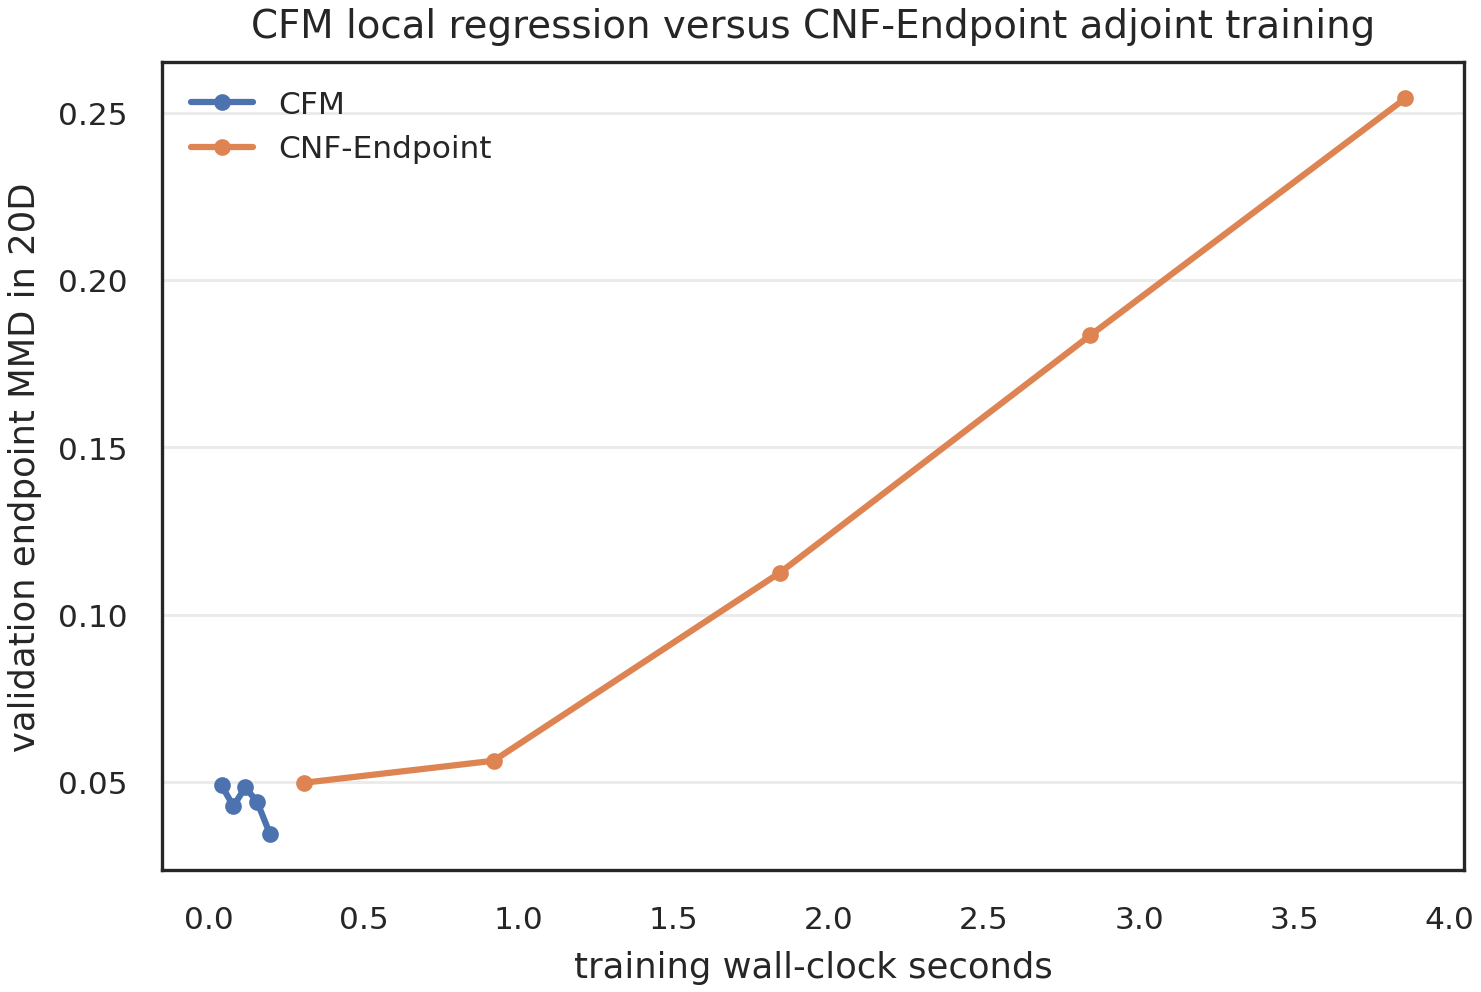

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE1_cfm_vs_cnf_endpoint_training_cost.png')

In [22]:
fig, ax = plt.subplots(figsize=(5.6, 3.5))
for method, group in e1_history.groupby("method", sort=False):
    ax.plot(group["wall_time_sec"], group["val_endpoint_mmd_20d"], marker="o", linewidth=1.5, markersize=3.0, label=method)
ax.set_xlabel("training wall-clock seconds")
ax.set_ylabel("validation endpoint MMD in 20D")
ax.set_title("CFM local regression versus CNF-Endpoint adjoint training")
ax.grid(axis="y", color="0.92", linewidth=0.7)
ax.legend(frameon=False)
e1_cost_path = tracker.save_figure(fig, "figE1_cfm_vs_cnf_endpoint_training_cost.png")
tracker.display_saved_figure(e1_cost_path, width=650)


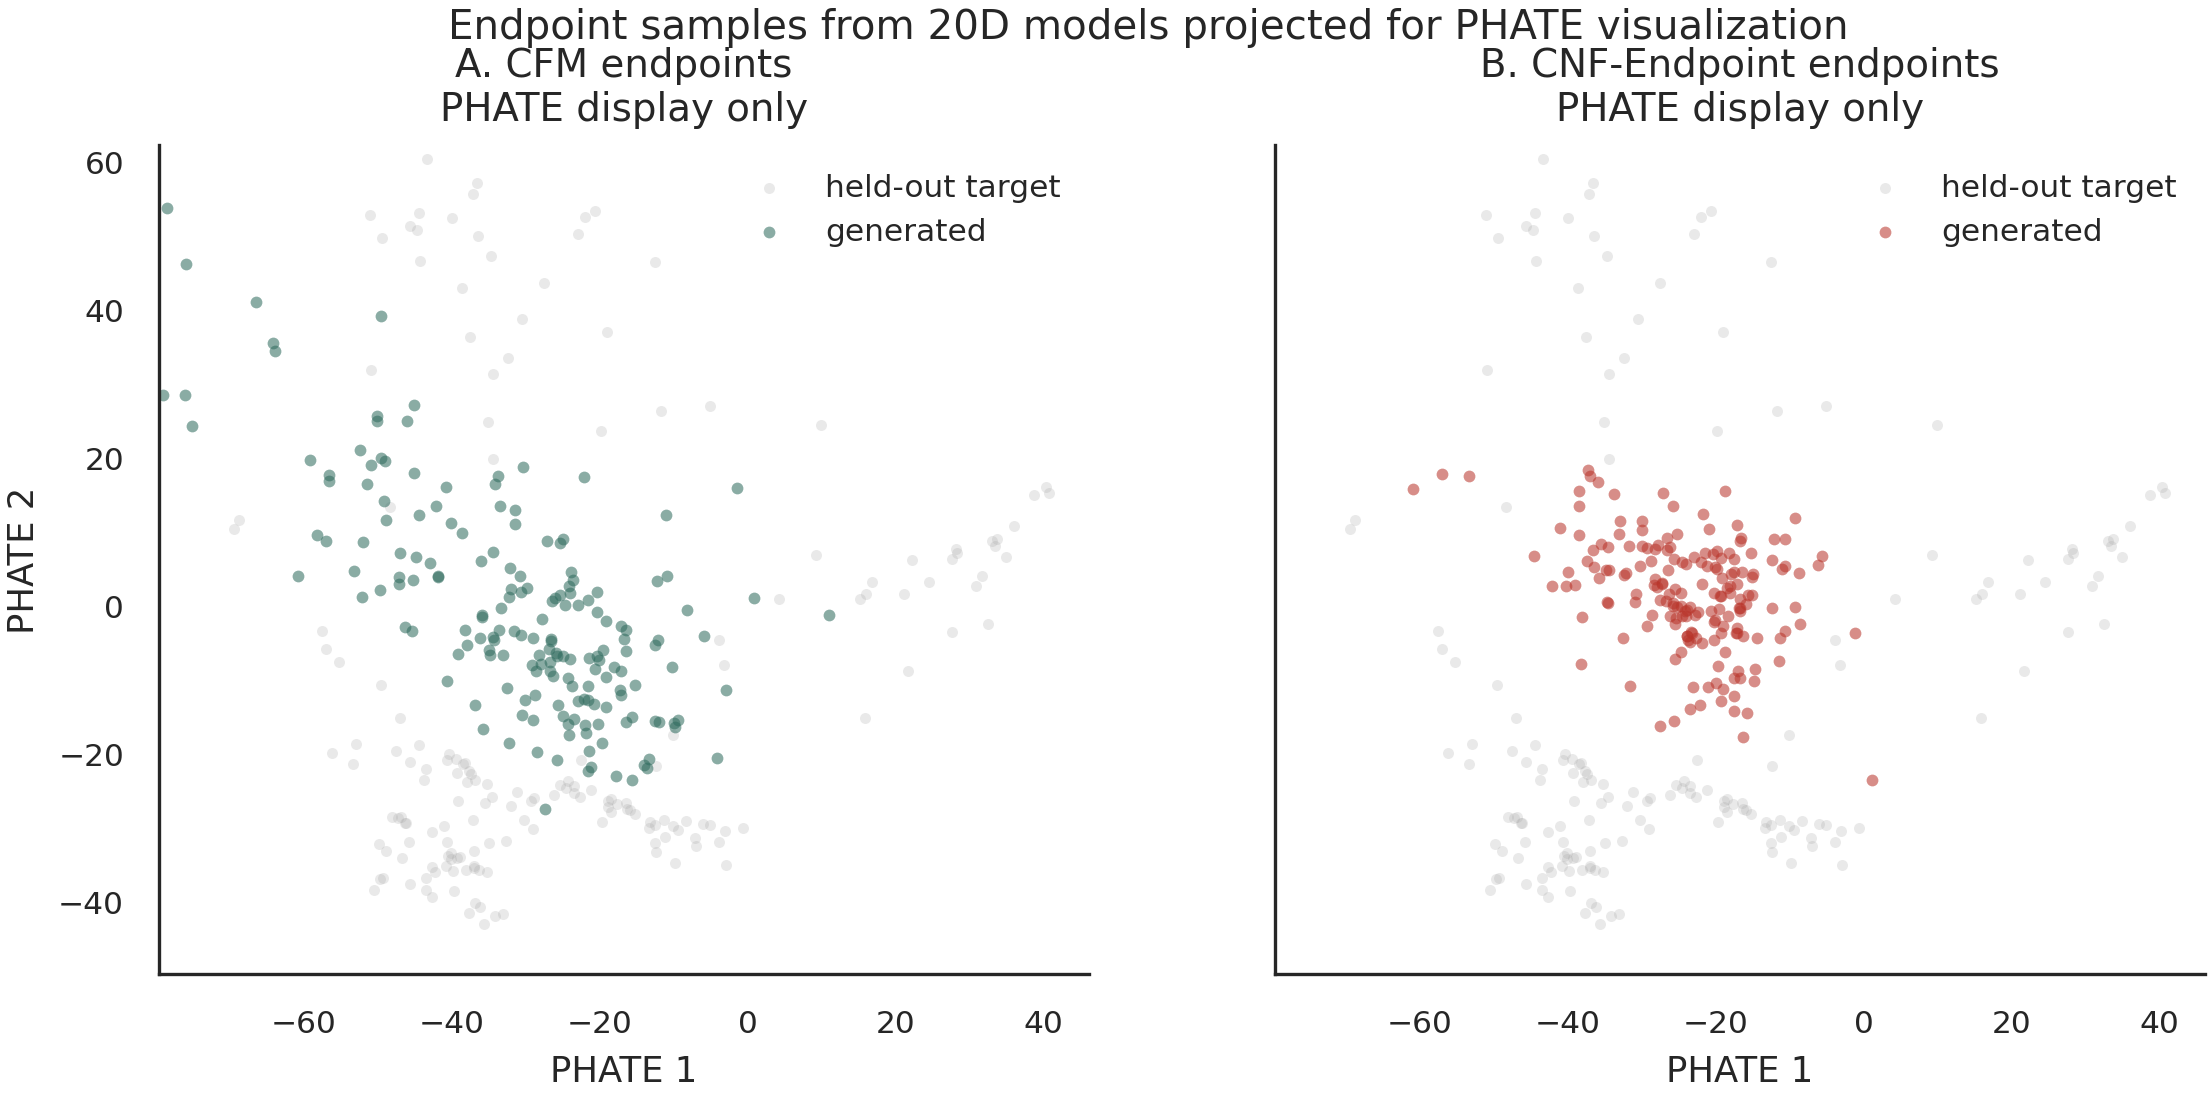

In [23]:
if cnf_e1_endpoint_20d is not None:
    cfm_plot = phate_projector.predict(cfm_e1_endpoint_20d)
    cnf_plot = phate_projector.predict(cnf_e1_endpoint_20d)
    target_plot = phate_projector.predict(e1_eval_target_20d)
    xlim, ylim = robust_limits(target_plot, cfm_plot, cnf_plot, margin=0.10)
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.8), sharex=True, sharey=True)
    panels = [(axes[0], cfm_plot, "A. CFM endpoints\nPHATE display only", "#2F6B5E"), (axes[1], cnf_plot, "B. CNF-Endpoint endpoints\nPHATE display only", "#B9352B")]
    for ax, pts, title, color in panels:
        ax.scatter(target_plot[:, 0], target_plot[:, 1], s=7, color="0.65", alpha=0.24, linewidths=0, label="held-out target")
        ax.scatter(pts[:, 0], pts[:, 1], s=8, color=color, alpha=0.56, linewidths=0, label="generated")
        format_axis(ax, xlim, ylim, xlabel="PHATE 1", ylabel="PHATE 2", title=title)
        ax.legend(frameon=False, loc="best")
        if ax is not axes[0]:
            ax.set_ylabel("")
    fig.suptitle("Endpoint samples from 20D models projected for PHATE visualization")
    e1_samples_path = tracker.save_figure(fig, "figE1_cfm_vs_cnf_endpoint_samples_phate.png")
    tracker.display_saved_figure(e1_samples_path, width=650)
else:
    ch03.record_skip(skipped_items, "figE1_cfm_vs_cnf_endpoint_samples_phate.png", "CNF-Endpoint did not complete")


### Claim boundary

This baseline only tests endpoint-loss adjoint training against local CFM regression on the EB endpoint-pair task. It does not make likelihood, divergence-estimation, or mechanistic lineage claims.


## 10. Time Sampling Strategy Ablation

### Question
Does changing the distribution of interpolation times used by the local CFM objective alter validation velocity MSE or endpoint distribution metrics?


### Configuration table

The model, endpoint pairs, optimizer, and evaluation set stay fixed. Only the training-time sampler for `t` changes.


In [24]:
time_sampling_completed = False

time_strategy_specs = [
    ("uniform", {}),
    ("logit_normal_sigma_0.5", {"sigma": 0.5}),
    ("logit_normal_sigma_1.0", {"sigma": 1.0}),
    ("logit_normal_sigma_2.0", {"sigma": 2.0}),
    ("beta_2_2", {"alpha": 2.0, "beta": 2.0}),
    ("beta_0.5_0.5", {"alpha": 0.5, "beta": 0.5}),
    ("cosine", {}),
]
time_steps = 350 if QUICK_MODE else 1200
time_batch_size = 192 if QUICK_MODE else 256
time_log_every = 70 if QUICK_MODE else 150
time_sample_steps = 30 if QUICK_MODE else 50
if SMOKE_MODE:
    time_steps = 8
    time_batch_size = 64
    time_log_every = 4
    time_sample_steps = 8

time_config = pd.DataFrame([
    {"strategy": strategy, "parameters": params, "steps": time_steps, "batch_size": time_batch_size, "sample_steps": time_sample_steps}
    for strategy, params in time_strategy_specs
])
tracker.display_table(time_config, n=8)


,strategy,parameters,steps,batch_size,sample_steps
0,uniform,{},350,192,30
1,logit_normal_sigma_0.5,{'sigma': 0.5},350,192,30
2,logit_normal_sigma_1.0,{'sigma': 1.0},350,192,30
3,logit_normal_sigma_2.0,{'sigma': 2.0},350,192,30
4,beta_2_2,"{'alpha': 2.0, 'beta': 2.0}",350,192,30
5,beta_0.5_0.5,"{'alpha': 0.5, 'beta': 0.5}",350,192,30
6,cosine,{},350,192,30


,strategy,parameters,steps,batch_size,sample_steps
0,uniform,{},350,192,30
1,logit_normal_sigma_0.5,{'sigma': 0.5},350,192,30
2,logit_normal_sigma_1.0,{'sigma': 1.0},350,192,30
3,logit_normal_sigma_2.0,{'sigma': 2.0},350,192,30
4,beta_2_2,"{'alpha': 2.0, 'beta': 2.0}",350,192,30
5,beta_0.5_0.5,"{'alpha': 0.5, 'beta': 0.5}",350,192,30
6,cosine,{},350,192,30


In [25]:
# Time sampling distributions live in src.ch03_tutorial.sample_t_numpy/sample_t_torch.


### Run

Each strategy trains an independent short CFM model and evaluates both validation velocity MSE and endpoint metrics.


In [26]:
def train_cfm_with_time_strategy(strategy, steps, batch_size, log_every, seed_offset=0):
    set_seed(SEED + 300 + seed_offset)
    model = VelocityMLP(x_dim=20, hidden_dim=256, hidden_layers=4).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    local_pair_batch = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 310 + seed_offset)
    rows = []
    start = time.perf_counter()
    last_time = start
    last_step = 0
    for step in range(1, int(steps) + 1):
        batch = local_pair_batch(batch_size)
        x0 = torch.as_tensor(batch["x0"], dtype=torch.float32, device=DEVICE)
        x1 = torch.as_tensor(batch["x1"], dtype=torch.float32, device=DEVICE)
        t_batch = ch03.sample_t_torch(strategy, batch_size, DEVICE, seed=SEED + 320 + seed_offset * 100000 + step, strategy_specs=dict(time_strategy_specs))
        loss = cfm_loss_from_pairs(model, x0, x1, s=t_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == 1 or step % int(log_every) == 0 or step == int(steps):
            now = time.perf_counter()
            val_mse = ch03.val_cfm_mse(model, val_x0, val_x1, val_t_grid, device=DEVICE, max_eval_pairs=900 if not SMOKE_MODE else 120, seed=SEED + 14)
            rows.append({"strategy": strategy, "step": int(step), "train_loss_20d": float(loss.detach().cpu()), "val_mse_20d": float(val_mse), "wall_time_sec": float(now - start), "sec_per_step": float((now - last_time) / max(1, step - last_step))})
            last_time = now
            last_step = step
    return model, pd.DataFrame(rows)


In [27]:
time_histories = []
time_summary_rows = []
for si, (strategy, _) in enumerate(time_strategy_specs):
    model, hist = train_cfm_with_time_strategy(strategy, time_steps, time_batch_size, time_log_every, seed_offset=si)
    endpoint_20d, sample_nfe, met = ch03.eval_cfm_endpoint_20d(model, e1_eval_x0_20d, e1_eval_target_20d, n_steps=time_sample_steps, seed=SEED + 400 + si, device=DEVICE, n_projections=metric_n_projections)
    hist["endpoint_mmd_20d"] = np.nan
    hist.loc[hist.index[-1], "endpoint_mmd_20d"] = met["endpoint_mmd_20d"]
    time_histories.append(hist)
    time_summary_rows.append({
        "strategy": strategy, "steps": int(time_steps),
        "final_train_loss_20d": float(hist["train_loss_20d"].iloc[-1]),
        "final_val_mse_20d": float(hist["val_mse_20d"].iloc[-1]),
        "endpoint_mmd_20d": met["endpoint_mmd_20d"], "sliced_w2_20d": met["sliced_w2_20d"],
        "sample_nfe": int(sample_nfe), "wall_time_sec": float(hist["wall_time_sec"].iloc[-1]),
    })

time_history = pd.concat(time_histories, ignore_index=True)
time_table = pd.DataFrame(time_summary_rows)
tracker.save_csv(time_table, "tableE3_time_sampling_ablation.csv")
time_sampling_completed = True
time_table


,strategy,steps,final_train_loss_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,uniform,350,6.088966,5.745028,0.015667,0.626032,30,0.571536
1,logit_normal_sigma_0.5,350,4.566753,5.929193,0.015344,0.950869,30,0.534570
2,logit_normal_sigma_1.0,350,5.239997,5.713410,0.013478,0.505581,30,0.536478
3,logit_normal_sigma_2.0,350,5.473126,5.707206,0.014937,0.562028,30,0.475675
4,beta_2_2,350,4.957688,5.753245,0.014437,0.614671,30,0.514064
5,beta_0.5_0.5,350,6.018308,5.963332,0.019460,0.622996,30,0.522826
6,cosine,350,5.338188,5.968984,0.018187,0.684906,30,0.503358


### Metrics table

This preview keeps the final metric rows readable before plotting them.


In [28]:
tracker.display_table(pd.read_csv(TABLE_DIR / "tableE3_time_sampling_ablation.csv"), n=8)


,strategy,steps,final_train_loss_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,uniform,350,6.088966,5.745028,0.015667,0.626032,30,0.571536
1,logit_normal_sigma_0.5,350,4.566753,5.929193,0.015344,0.950869,30,0.534570
2,logit_normal_sigma_1.0,350,5.239997,5.713410,0.013478,0.505581,30,0.536478
3,logit_normal_sigma_2.0,350,5.473126,5.707206,0.014937,0.562028,30,0.475675
4,beta_2_2,350,4.957688,5.753245,0.014437,0.614671,30,0.514064
5,beta_0.5_0.5,350,6.018308,5.963332,0.019460,0.622996,30,0.522826
6,cosine,350,5.338188,5.968984,0.018187,0.684906,30,0.503358


,strategy,steps,final_train_loss_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,uniform,350,6.088966,5.745028,0.015667,0.626032,30,0.571536
1,logit_normal_sigma_0.5,350,4.566753,5.929193,0.015344,0.950869,30,0.534570
2,logit_normal_sigma_1.0,350,5.239997,5.713410,0.013478,0.505581,30,0.536478
3,logit_normal_sigma_2.0,350,5.473126,5.707206,0.014937,0.562028,30,0.475675
4,beta_2_2,350,4.957688,5.753245,0.014437,0.614671,30,0.514064
5,beta_0.5_0.5,350,6.018308,5.963332,0.019460,0.622996,30,0.522826
6,cosine,350,5.338188,5.968984,0.018187,0.684906,30,0.503358


### Figure

The four E3 figures show the sampled `t` distributions, validation MSE curves, endpoint MMD ranking, and final endpoint metrics.


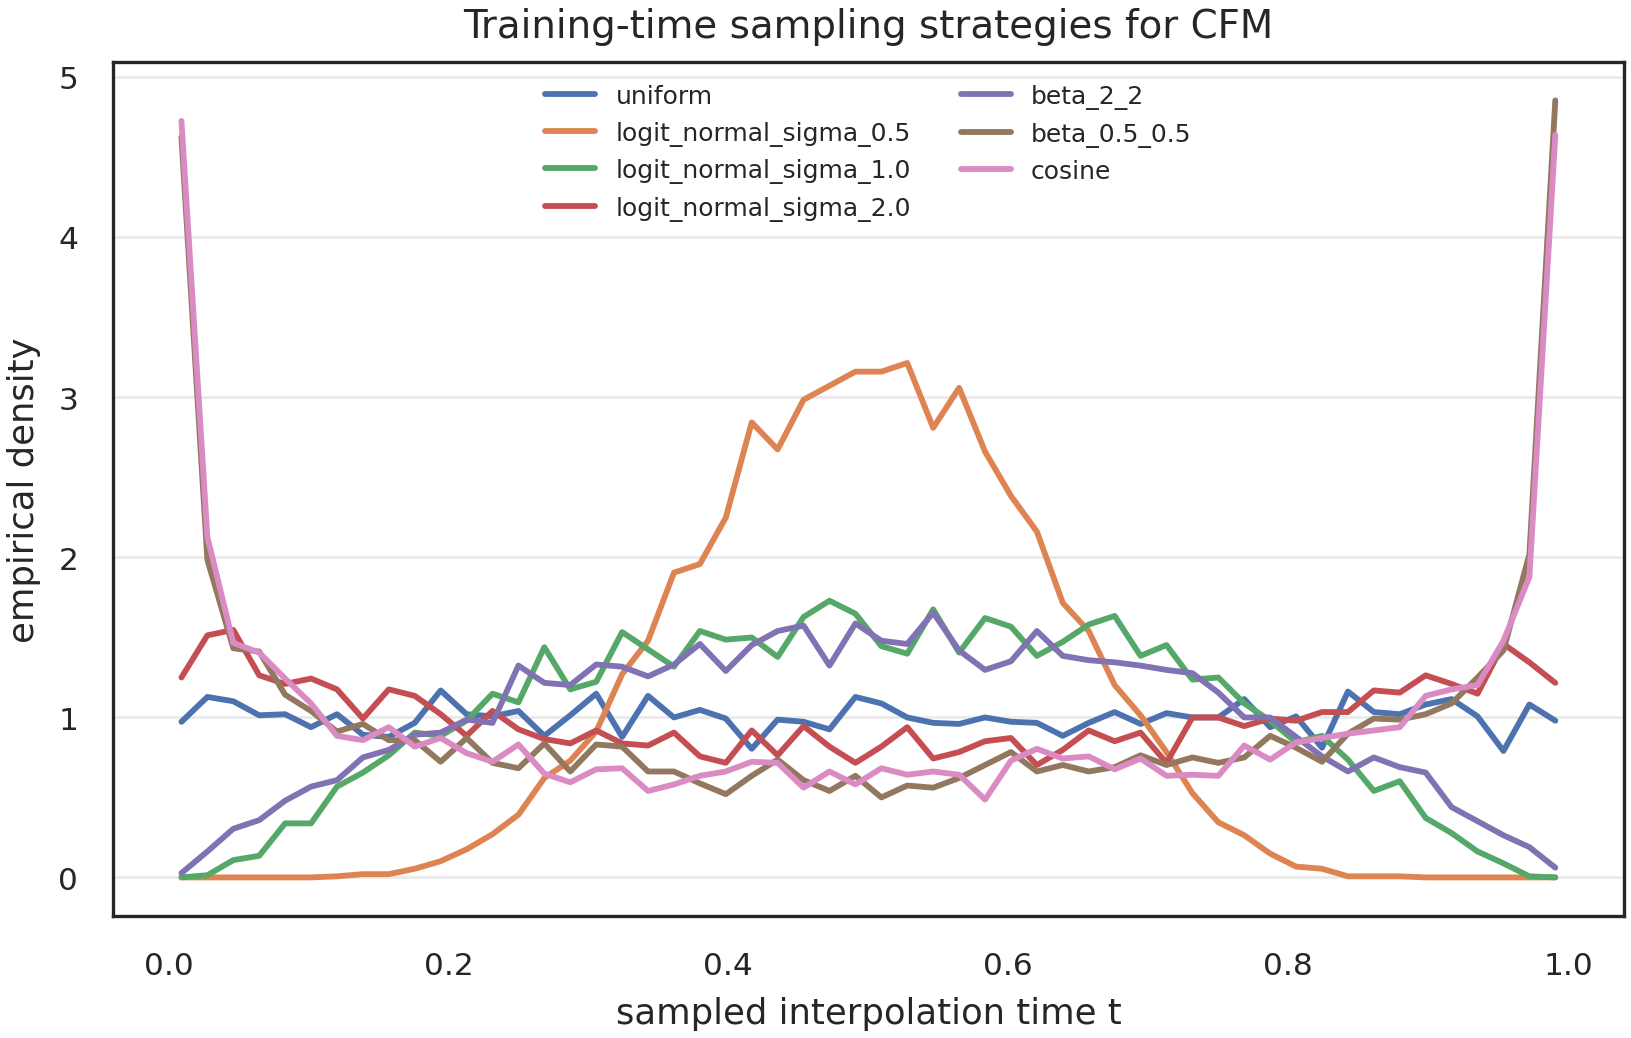

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE3_time_sampling_distributions.png')

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 3.7))
bins = np.linspace(0.0, 1.0, 55)
for i, (strategy, _) in enumerate(time_strategy_specs):
    samples = ch03.sample_t_numpy(strategy, 8000 if not SMOKE_MODE else 1200, seed=SEED + 330 + i, strategy_specs=dict(time_strategy_specs))
    hist, edges = np.histogram(samples, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, hist, linewidth=1.4, label=strategy)
ax.set_xlabel("sampled interpolation time t")
ax.set_ylabel("empirical density")
ax.set_title("Training-time sampling strategies for CFM")
ax.legend(frameon=False, fontsize=6, ncol=2)
ax.grid(axis="y", color="0.92", linewidth=0.7)
time_dist_path = tracker.save_figure(fig, "figE3_time_sampling_distributions.png")
tracker.display_saved_figure(time_dist_path, width=650)


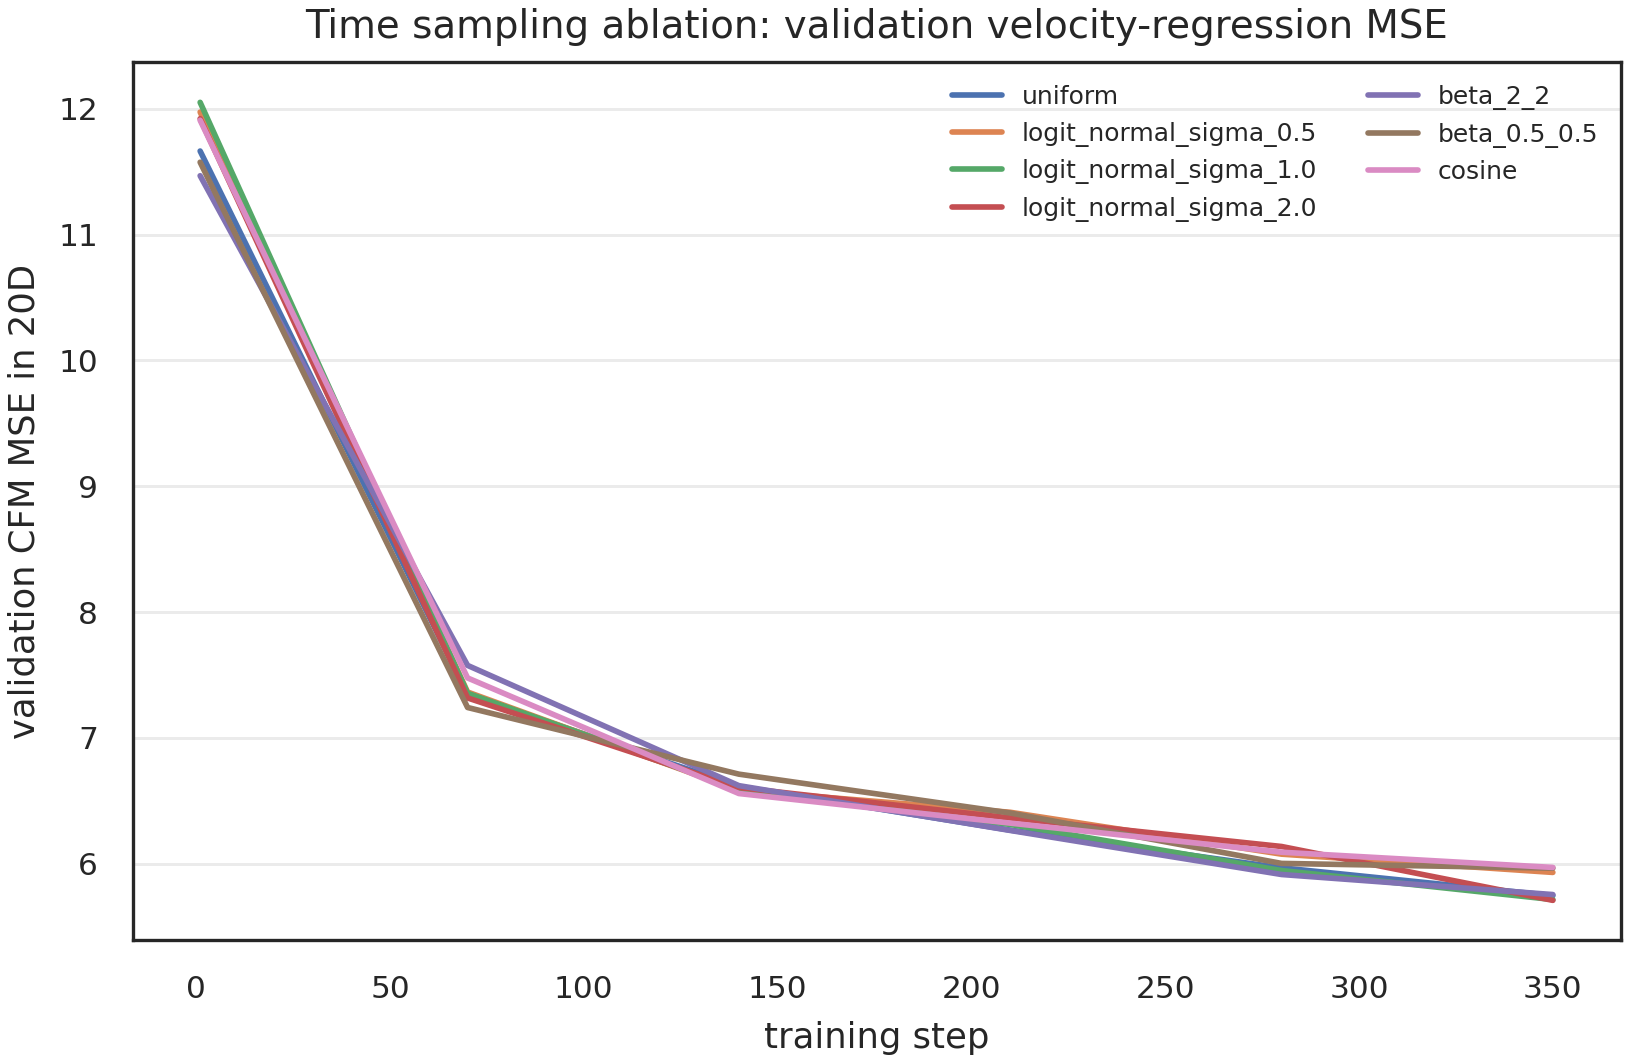

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE3_time_sampling_val_mse.png')

In [30]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for strategy, group in time_history.groupby("strategy", sort=False):
    ax.plot(group["step"], group["val_mse_20d"], linewidth=1.35, label=strategy)
ax.set_xlabel("training step")
ax.set_ylabel("validation CFM MSE in 20D")
ax.set_title("Time sampling ablation: validation velocity-regression MSE")
ax.grid(axis="y", color="0.92", linewidth=0.7)
ax.legend(frameon=False, fontsize=6, ncol=2)
time_val_path = tracker.save_figure(fig, "figE3_time_sampling_val_mse.png")
tracker.display_saved_figure(time_val_path, width=650)


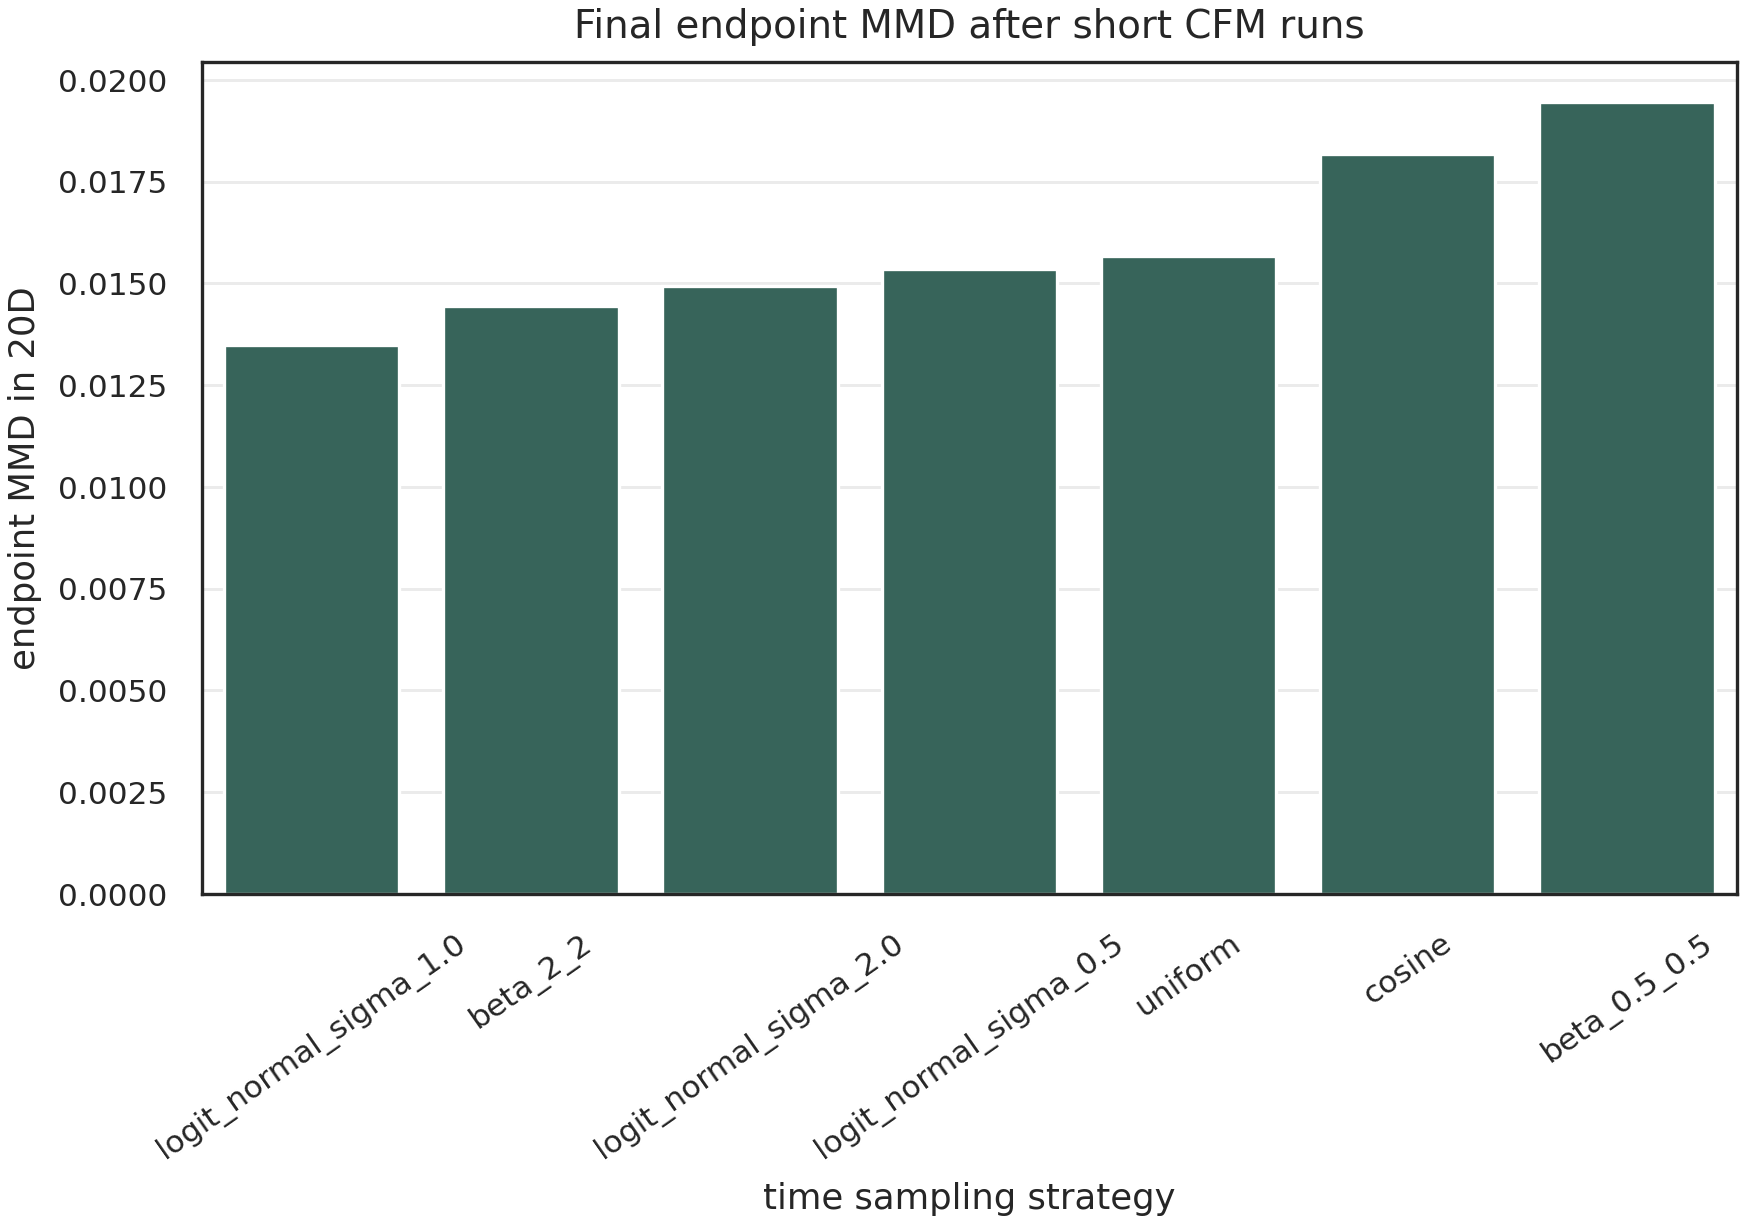

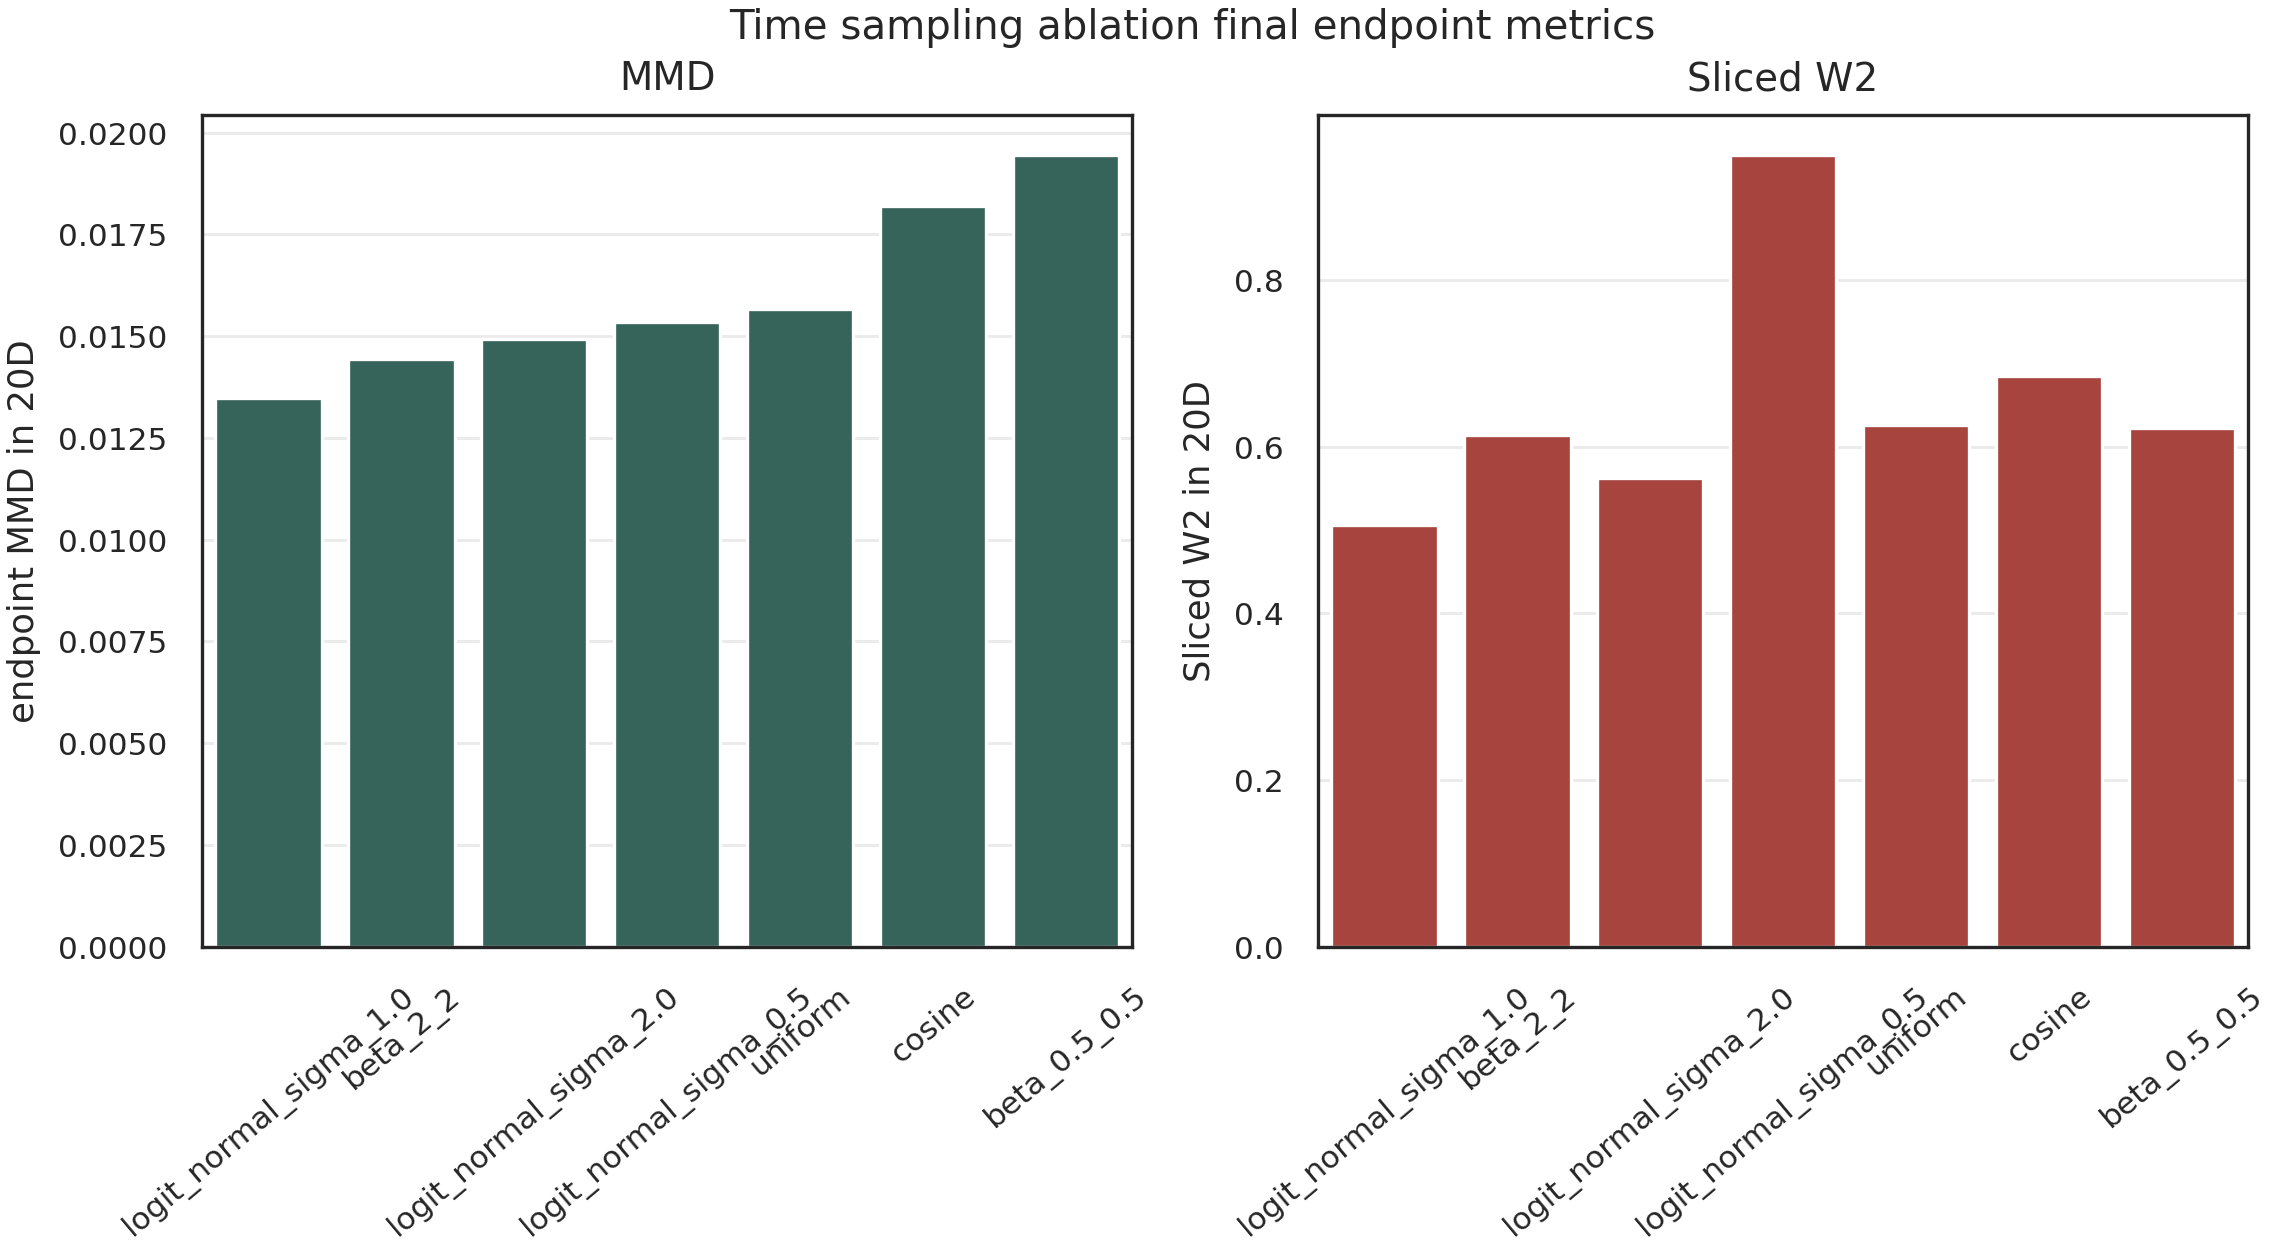

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE3_time_sampling_final_bar.png')

In [31]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
order = time_table.sort_values("endpoint_mmd_20d")["strategy"].tolist()
sns.barplot(data=time_table, x="strategy", y="endpoint_mmd_20d", order=order, ax=ax, color="#2F6B5E")
ax.set_xlabel("time sampling strategy")
ax.set_ylabel("endpoint MMD in 20D")
ax.set_title("Final endpoint MMD after short CFM runs")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", color="0.92", linewidth=0.7)
time_mmd_path = tracker.save_figure(fig, "figE3_time_sampling_endpoint_mmd.png")
tracker.display_saved_figure(time_mmd_path, width=650)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.6))
sns.barplot(data=time_table, x="strategy", y="endpoint_mmd_20d", order=order, ax=axes[0], color="#2F6B5E")
sns.barplot(data=time_table, x="strategy", y="sliced_w2_20d", order=order, ax=axes[1], color="#B9352B")
for ax, ylabel in zip(axes, ["endpoint MMD in 20D", "Sliced W2 in 20D"]):
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=40)
    ax.grid(axis="y", color="0.92", linewidth=0.7)
axes[0].set_title("MMD")
axes[1].set_title("Sliced W2")
fig.suptitle("Time sampling ablation final endpoint metrics")
time_bar_path = tracker.save_figure(fig, "figE3_time_sampling_final_bar.png")
tracker.display_saved_figure(time_bar_path, width=650)


### Claim boundary

This ablation compares short-run training-time samplers under a fixed endpoint-pair task. It does not establish a universal optimal time distribution or a biological mechanism.


## 11. Network Capacity Ablation

### Question
How sensitive are validation velocity MSE and endpoint distribution metrics to VelocityMLP capacity on the same EB endpoint-pair task?


### Configuration table

Capacity changes hidden width/depth. The task, optimizer, pair source, and endpoint evaluation remain fixed.


In [32]:
capacity_ablation_completed = False
capacity_configs = [
    {"config": "tiny", "hidden_dim": 64, "hidden_layers": 3},
    {"config": "small", "hidden_dim": 128, "hidden_layers": 4},
    {"config": "medium", "hidden_dim": 256, "hidden_layers": 4},
]
if not QUICK_MODE:
    capacity_configs.append({"config": "large", "hidden_dim": 512, "hidden_layers": 6})

capacity_steps = 300 if QUICK_MODE else 1200
capacity_batch_size = 192 if QUICK_MODE else 256
capacity_log_every = 100 if QUICK_MODE else 200
capacity_sample_steps = 30 if QUICK_MODE else 50
if SMOKE_MODE:
    capacity_steps = 8
    capacity_batch_size = 64
    capacity_log_every = 4
    capacity_sample_steps = 8

capacity_config_table = pd.DataFrame([
    {**cfg, "steps": capacity_steps, "batch_size": capacity_batch_size, "sample_steps": capacity_sample_steps}
    for cfg in capacity_configs
])
tracker.display_table(capacity_config_table, n=8)


,config,hidden_dim,hidden_layers,steps,batch_size,sample_steps
0,tiny,64,3,300,192,30
1,small,128,4,300,192,30
2,medium,256,4,300,192,30


,config,hidden_dim,hidden_layers,steps,batch_size,sample_steps
0,tiny,64,3,300,192,30
1,small,128,4,300,192,30
2,medium,256,4,300,192,30


### Run

Each model is trained from a seed-offset initialization, evaluated on the same validation pairs, and summarized into the T2 hyperparameter table.


In [33]:
capacity_rows = []
capacity_histories = []
for ci, cfg in enumerate(capacity_configs):
    set_seed(SEED + 500 + ci)
    model = VelocityMLP(x_dim=20, hidden_dim=cfg["hidden_dim"], hidden_layers=cfg["hidden_layers"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    local_pair_batch = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 510 + ci)
    start = time.perf_counter()
    last_loss = np.nan
    hist_rows = []
    for step in range(1, int(capacity_steps) + 1):
        batch = local_pair_batch(capacity_batch_size)
        x0 = torch.as_tensor(batch["x0"], dtype=torch.float32, device=DEVICE)
        x1 = torch.as_tensor(batch["x1"], dtype=torch.float32, device=DEVICE)
        loss = cfm_loss_from_pairs(model, x0, x1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        last_loss = float(loss.detach().cpu())
        if step == 1 or step % capacity_log_every == 0 or step == int(capacity_steps):
            val_mse = ch03.val_cfm_mse(model, val_x0, val_x1, val_t_grid, device=DEVICE, max_eval_pairs=900 if not SMOKE_MODE else 120, seed=SEED + 14)
            hist_rows.append({"config": cfg["config"], "step": int(step), "train_loss_20d": last_loss, "val_mse_20d": val_mse})
    wall = time.perf_counter() - start
    endpoint_20d, sample_nfe, met = ch03.eval_cfm_endpoint_20d(model, e1_eval_x0_20d, e1_eval_target_20d, n_steps=capacity_sample_steps, seed=SEED + 540 + ci, device=DEVICE, n_projections=metric_n_projections)
    hist = pd.DataFrame(hist_rows)
    capacity_histories.append(hist)
    capacity_rows.append({
        "config": cfg["config"], "input_dim": 20, "output_dim": 20, "hidden_dim": int(cfg["hidden_dim"]),
        "hidden_layers": int(cfg["hidden_layers"]), "n_parameters": int(count_parameters(model)), "lr": 1e-3,
        "batch_size": int(capacity_batch_size), "steps": int(capacity_steps), "final_train_mse_20d": float(last_loss),
        "final_val_mse_20d": float(hist["val_mse_20d"].iloc[-1]), "endpoint_mmd_20d": met["endpoint_mmd_20d"],
        "sliced_w2_20d": met["sliced_w2_20d"], "sample_nfe": int(sample_nfe), "wall_time_sec": float(wall),
    })

capacity_table = pd.DataFrame(capacity_rows)
capacity_history = pd.concat(capacity_histories, ignore_index=True)
tracker.save_csv(capacity_table, "tableT2_training_hyperparams_capacity.csv")
capacity_ablation_completed = True
capacity_table


,config,input_dim,output_dim,hidden_dim,hidden_layers,n_parameters,lr,batch_size,steps,final_train_mse_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,tiny,20,20,64,3,11028,0.001,192,300,5.679418,6.644771,0.019059,0.591565,30,0.390349
1,small,20,20,128,4,54932,0.001,192,300,5.898505,6.389340,0.015732,0.604457,30,0.435444
2,medium,20,20,256,4,208148,0.001,192,300,6.073959,5.915458,0.014370,0.563049,30,0.434212


### Metrics table

The table includes model size, optimization settings, final velocity MSE, and endpoint distribution metrics.


In [34]:
tracker.display_table(pd.read_csv(TABLE_DIR / "tableT2_training_hyperparams_capacity.csv"), n=8)


,config,input_dim,output_dim,hidden_dim,hidden_layers,n_parameters,lr,batch_size,steps,final_train_mse_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,tiny,20,20,64,3,11028,0.001,192,300,5.679418,6.644771,0.019059,0.591565,30,0.390349
1,small,20,20,128,4,54932,0.001,192,300,5.898505,6.389340,0.015732,0.604457,30,0.435444
2,medium,20,20,256,4,208148,0.001,192,300,6.073959,5.915458,0.014370,0.563049,30,0.434212


,config,input_dim,output_dim,hidden_dim,hidden_layers,n_parameters,lr,batch_size,steps,final_train_mse_20d,final_val_mse_20d,endpoint_mmd_20d,sliced_w2_20d,sample_nfe,wall_time_sec
0,tiny,20,20,64,3,11028,0.001,192,300,5.679418,6.644771,0.019059,0.591565,30,0.390349
1,small,20,20,128,4,54932,0.001,192,300,5.898505,6.389340,0.015732,0.604457,30,0.435444
2,medium,20,20,256,4,208148,0.001,192,300,6.073959,5.915458,0.014370,0.563049,30,0.434212


### Figure

The E2 figures plot parameter count against validation MSE and endpoint MMD.


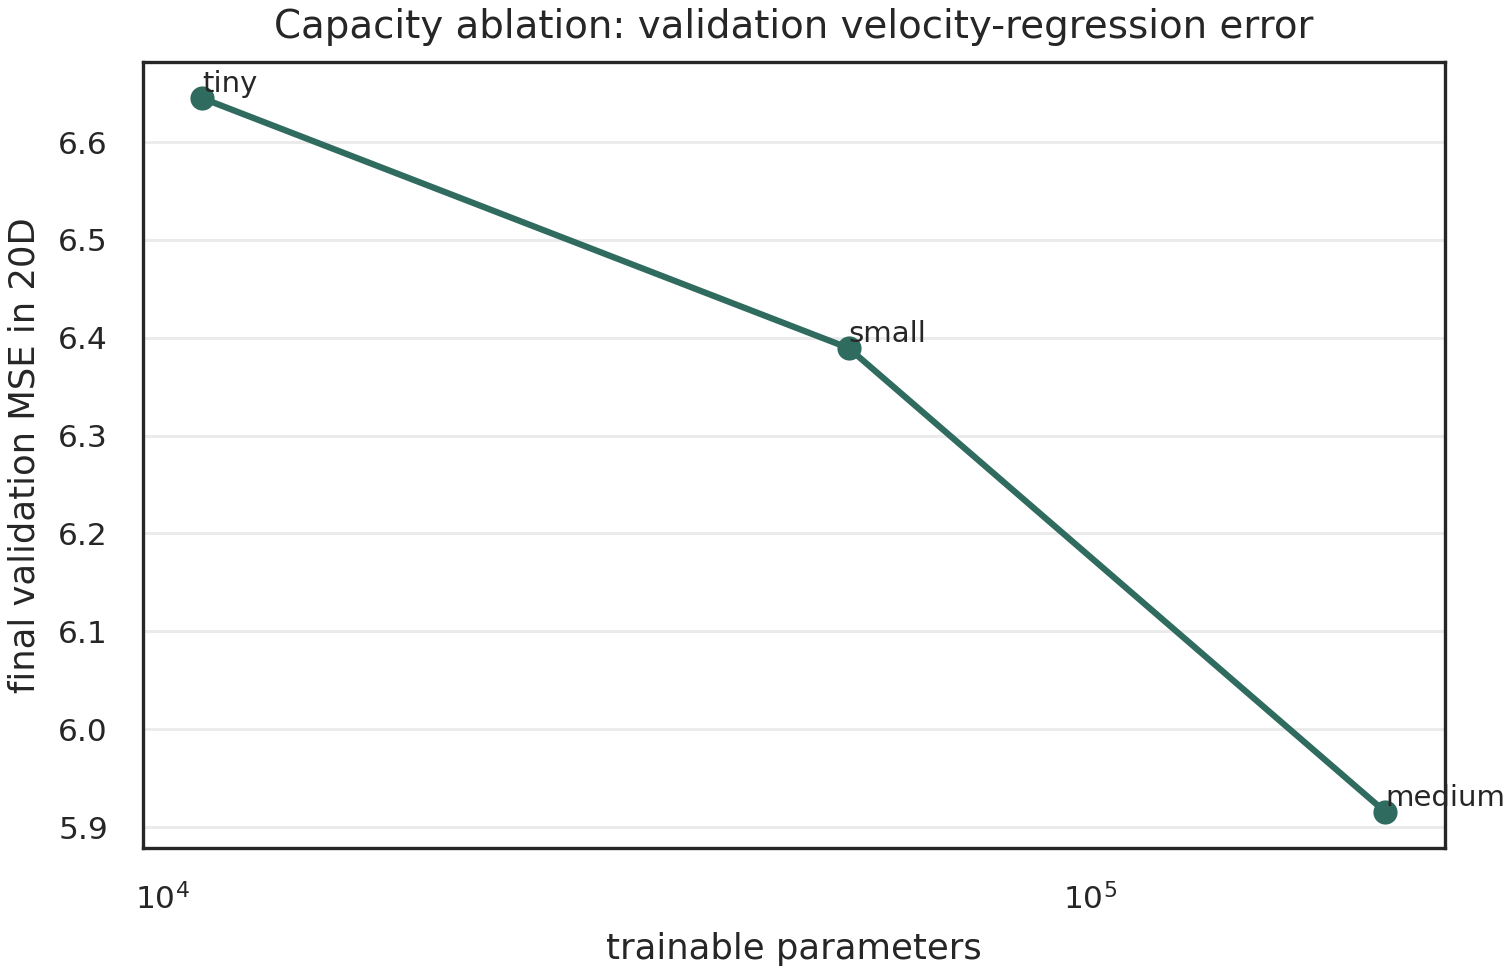

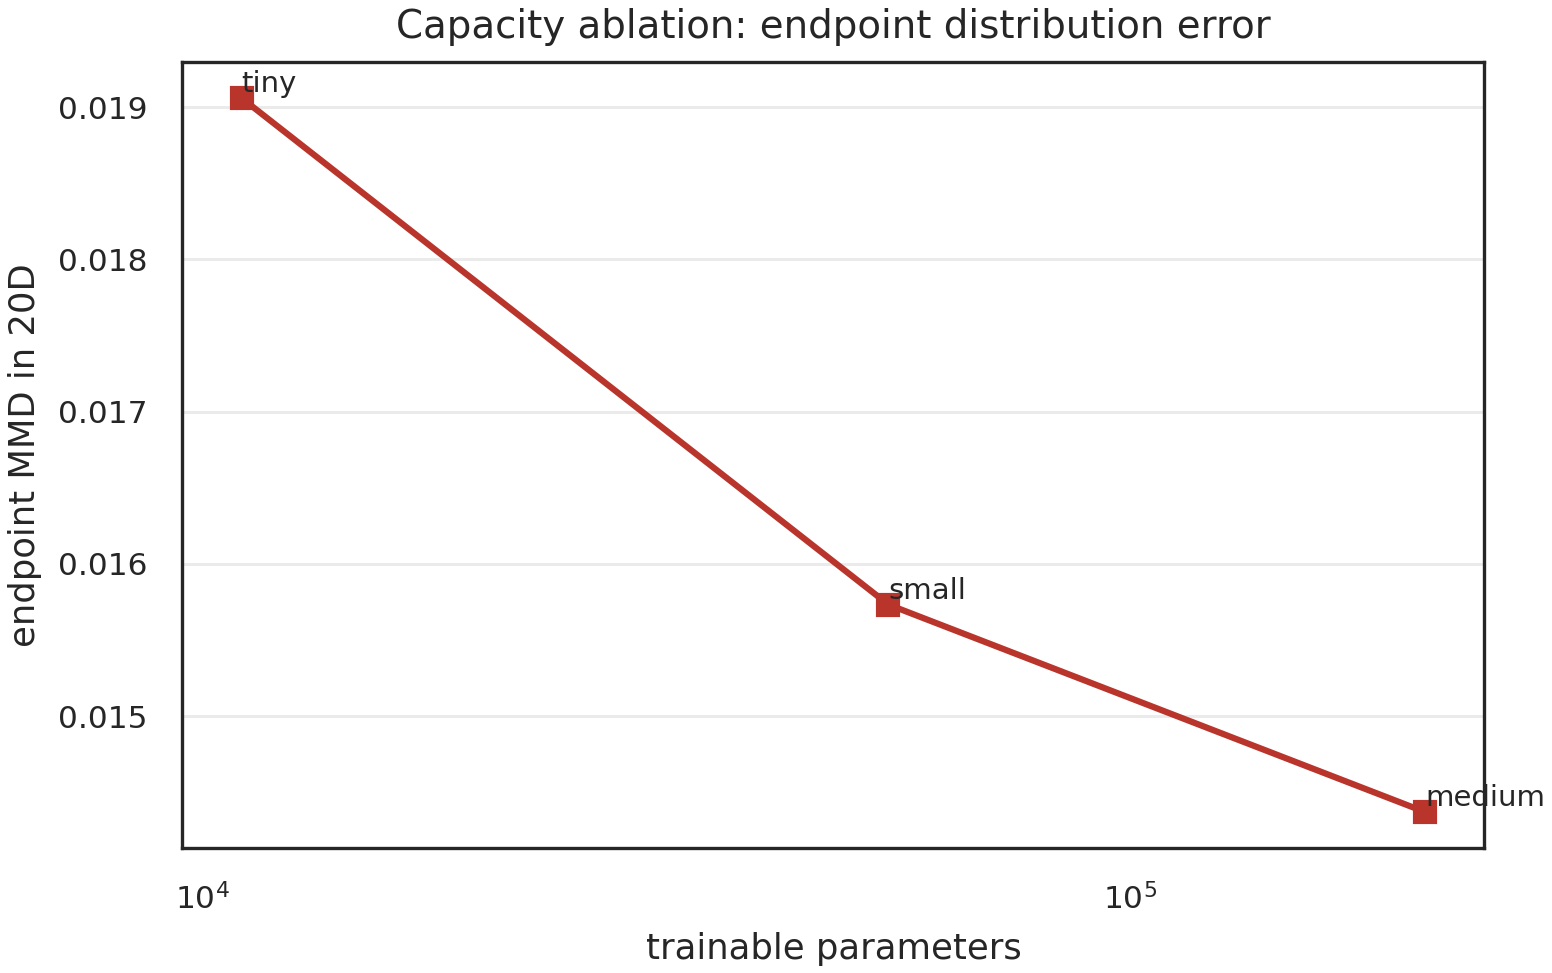

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE2_capacity_endpoint_mmd.png')

In [35]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(capacity_table["n_parameters"], capacity_table["final_val_mse_20d"], marker="o", linewidth=1.5, color="#2F6B5E")
for _, row in capacity_table.iterrows():
    ax.text(row["n_parameters"], row["final_val_mse_20d"], row["config"], fontsize=7, ha="left", va="bottom")
ax.set_xscale("log")
ax.set_xlabel("trainable parameters")
ax.set_ylabel("final validation MSE in 20D")
ax.set_title("Capacity ablation: validation velocity-regression error")
ax.grid(axis="y", color="0.92", linewidth=0.7)
capacity_val_path = tracker.save_figure(fig, "figE2_capacity_val_mse.png")
tracker.display_saved_figure(capacity_val_path, width=650)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(capacity_table["n_parameters"], capacity_table["endpoint_mmd_20d"], marker="s", linewidth=1.5, color="#B9352B")
for _, row in capacity_table.iterrows():
    ax.text(row["n_parameters"], row["endpoint_mmd_20d"], row["config"], fontsize=7, ha="left", va="bottom")
ax.set_xscale("log")
ax.set_xlabel("trainable parameters")
ax.set_ylabel("endpoint MMD in 20D")
ax.set_title("Capacity ablation: endpoint distribution error")
ax.grid(axis="y", color="0.92", linewidth=0.7)
capacity_mmd_path = tracker.save_figure(fig, "figE2_capacity_endpoint_mmd.png")
tracker.display_saved_figure(capacity_mmd_path, width=650)


### Claim boundary

This ablation reports finite-budget behavior for a small set of VelocityMLP capacities. It does not prove that the largest tested network is globally best or that capacity alone explains biological transition quality.


## 12. Trajectory Straightness in 20D

### Question
How straight are the numerical paths generated by the main EB CFM sampler in the 20D training space?

A straightness ratio near 1 means the sampled numerical path length is close to its endpoint displacement.


### Configuration table

The diagnostic uses the cached main EB CFM model. PHATE appears only after the 20D straightness scores are computed, for representative trajectory display.


In [36]:
straightness_completed = False
straight_sample_n = min(900 if QUICK_MODE else 1600, len(X0_val))
straight_steps = 50 if QUICK_MODE else 100
if SMOKE_MODE:
    straight_sample_n = min(120, len(X0_val))
    straight_steps = 10

straight_config = pd.DataFrame([{
    "model": "cached EB CFM", "sample_n": straight_sample_n, "euler_steps": straight_steps,
    "metric_space": "20D PC X_cost", "display_space": "PHATE X_plot only",
}])
tracker.display_table(straight_config, n=4)


,model,sample_n,euler_steps,metric_space,display_space
0,cached EB CFM,180,50,20D PC X_cost,PHATE X_plot only


,model,sample_n,euler_steps,metric_space,display_space
0,cached EB CFM,180,50,20D PC X_cost,PHATE X_plot only


### Run

The sampler returns full 20D trajectories. The table records path length, endpoint displacement, straightness ratio, and quantile group for each sampled trajectory.


In [37]:
straight_idx = subsample_idx(len(X0_val), straight_sample_n, seed=SEED + 600)
straight_x0_t = torch.as_tensor(X0_val[straight_idx], dtype=torch.float32, device=DEVICE)
eb_model.eval()
with torch.no_grad():
    straight_endpoint_t, straight_traj_t, straight_nfe = euler_sample(eb_model, straight_x0_t, n_steps=straight_steps, return_traj=True)
straight_traj_20d = as_np(straight_traj_t)
path_length_20d, endpoint_distance_20d, straight_ratio = ch03.per_trajectory_straightness(straight_traj_20d)
q25, q50, q75, q90 = np.quantile(straight_ratio, [0.25, 0.50, 0.75, 0.90])
quantile_group = np.full(straight_ratio.shape, "middle", dtype=object)
quantile_group[straight_ratio <= q25] = "lower_quantile"
quantile_group[straight_ratio >= q75] = "upper_quantile"
straight_table = pd.DataFrame({
    "cell_index": straight_idx.astype(int),
    "endpoint_distance_20d": endpoint_distance_20d,
    "path_length_20d": path_length_20d,
    "straightness_ratio_20d": straight_ratio,
    "quantile_group": quantile_group,
})
tracker.save_csv(straight_table, "tableE5_trajectory_straightness.csv")
straightness_completed = True
straight_table.describe(include="all")


,cell_index,endpoint_distance_20d,path_length_20d,straightness_ratio_20d,quantile_group
count,180.000000,180.000000,180.000000,180.000000,180
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,middle
freq,NaN,NaN,NaN,NaN,90
mean,89.500000,11.139757,11.728964,1.065891,NaN
std,52.105662,3.610021,3.416814,0.061734,NaN
min,0.000000,5.601408,6.236039,1.007185,NaN
25%,44.750000,7.971909,8.683022,1.025083,NaN
50%,89.500000,10.701778,11.355150,1.046332,NaN
75%,134.250000,13.708074,14.041625,1.091486,NaN


### Metrics table

The preview shows representative per-trajectory rows; the paper export later summarizes the distribution.


In [38]:
tracker.display_table(pd.read_csv(TABLE_DIR / "tableE5_trajectory_straightness.csv"), n=8)


,cell_index,endpoint_distance_20d,path_length_20d,straightness_ratio_20d,quantile_group
0,0,8.328905,9.193706,1.103831,upper_quantile
1,1,11.917112,12.519520,1.050550,middle
2,2,6.809344,7.351447,1.079612,middle
3,3,14.976532,15.475112,1.033291,middle
4,4,11.753957,12.685069,1.079217,middle
5,5,9.269182,9.708201,1.047363,middle
6,6,7.207734,7.669842,1.064113,middle
7,7,7.896138,8.661254,1.096897,upper_quantile


,cell_index,endpoint_distance_20d,path_length_20d,straightness_ratio_20d,quantile_group
0,0,8.328905,9.193706,1.103831,upper_quantile
1,1,11.917112,12.519520,1.050550,middle
2,2,6.809344,7.351447,1.079612,middle
3,3,14.976532,15.475112,1.033291,middle
4,4,11.753957,12.685069,1.079217,middle
5,5,9.269182,9.708201,1.047363,middle
6,6,7.207734,7.669842,1.064113,middle
7,7,7.896138,8.661254,1.096897,upper_quantile


### Figure

The E5 figures display the straightness distribution, endpoint-distance relationship, and representative trajectories projected to PHATE after scoring in 20D.


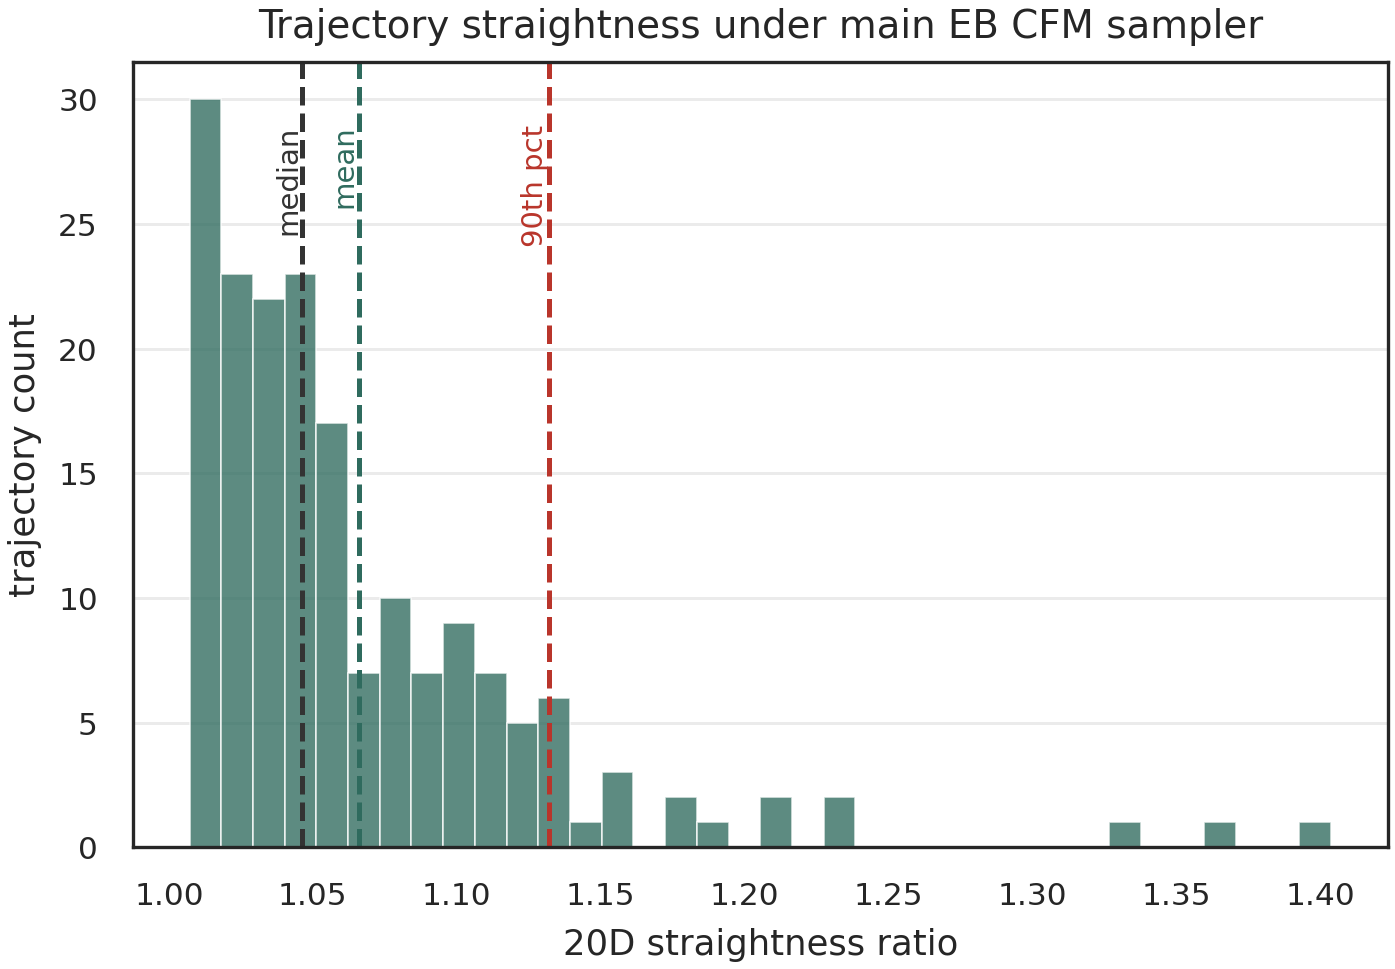

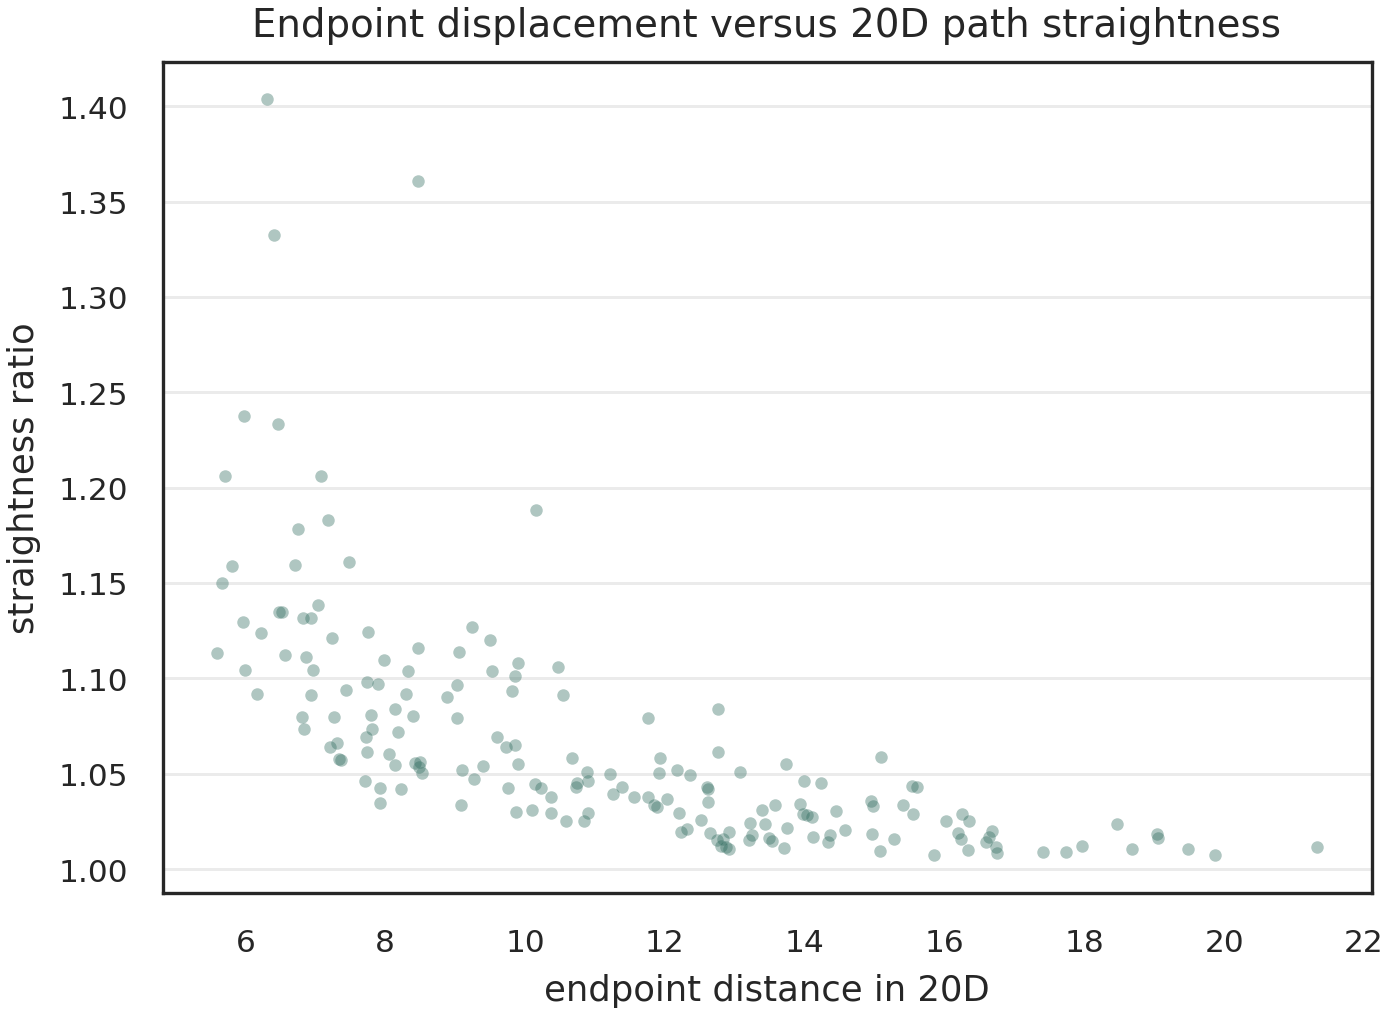

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE5_endpoint_distance_vs_straightness.png')

In [39]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.hist(straight_ratio, bins=36, color="#2F6B5E", alpha=0.78, edgecolor="white", linewidth=0.4)
for value, label, color in [(straight_ratio.mean(), "mean", "#2F6B5E"), (q50, "median", "0.20"), (q90, "90th pct", "#B9352B")]:
    ax.axvline(value, color=color, linestyle="--", linewidth=1.2)
    ax.text(value, ax.get_ylim()[1] * 0.92, label, rotation=90, va="top", ha="right", fontsize=7, color=color)
ax.set_xlabel("20D straightness ratio")
ax.set_ylabel("trajectory count")
ax.set_title("Trajectory straightness under main EB CFM sampler")
ax.grid(axis="y", color="0.92", linewidth=0.7)
straight_hist_path = tracker.save_figure(fig, "figE5_straightness_hist.png")
tracker.display_saved_figure(straight_hist_path, width=650)

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.scatter(endpoint_distance_20d, straight_ratio, s=9, color="#2F6B5E", alpha=0.38, linewidths=0)
ax.set_xlabel("endpoint distance in 20D")
ax.set_ylabel("straightness ratio")
ax.set_title("Endpoint displacement versus 20D path straightness")
ax.grid(axis="y", color="0.92", linewidth=0.7)
straight_scatter_path = tracker.save_figure(fig, "figE5_endpoint_distance_vs_straightness.png")
tracker.display_saved_figure(straight_scatter_path, width=650)


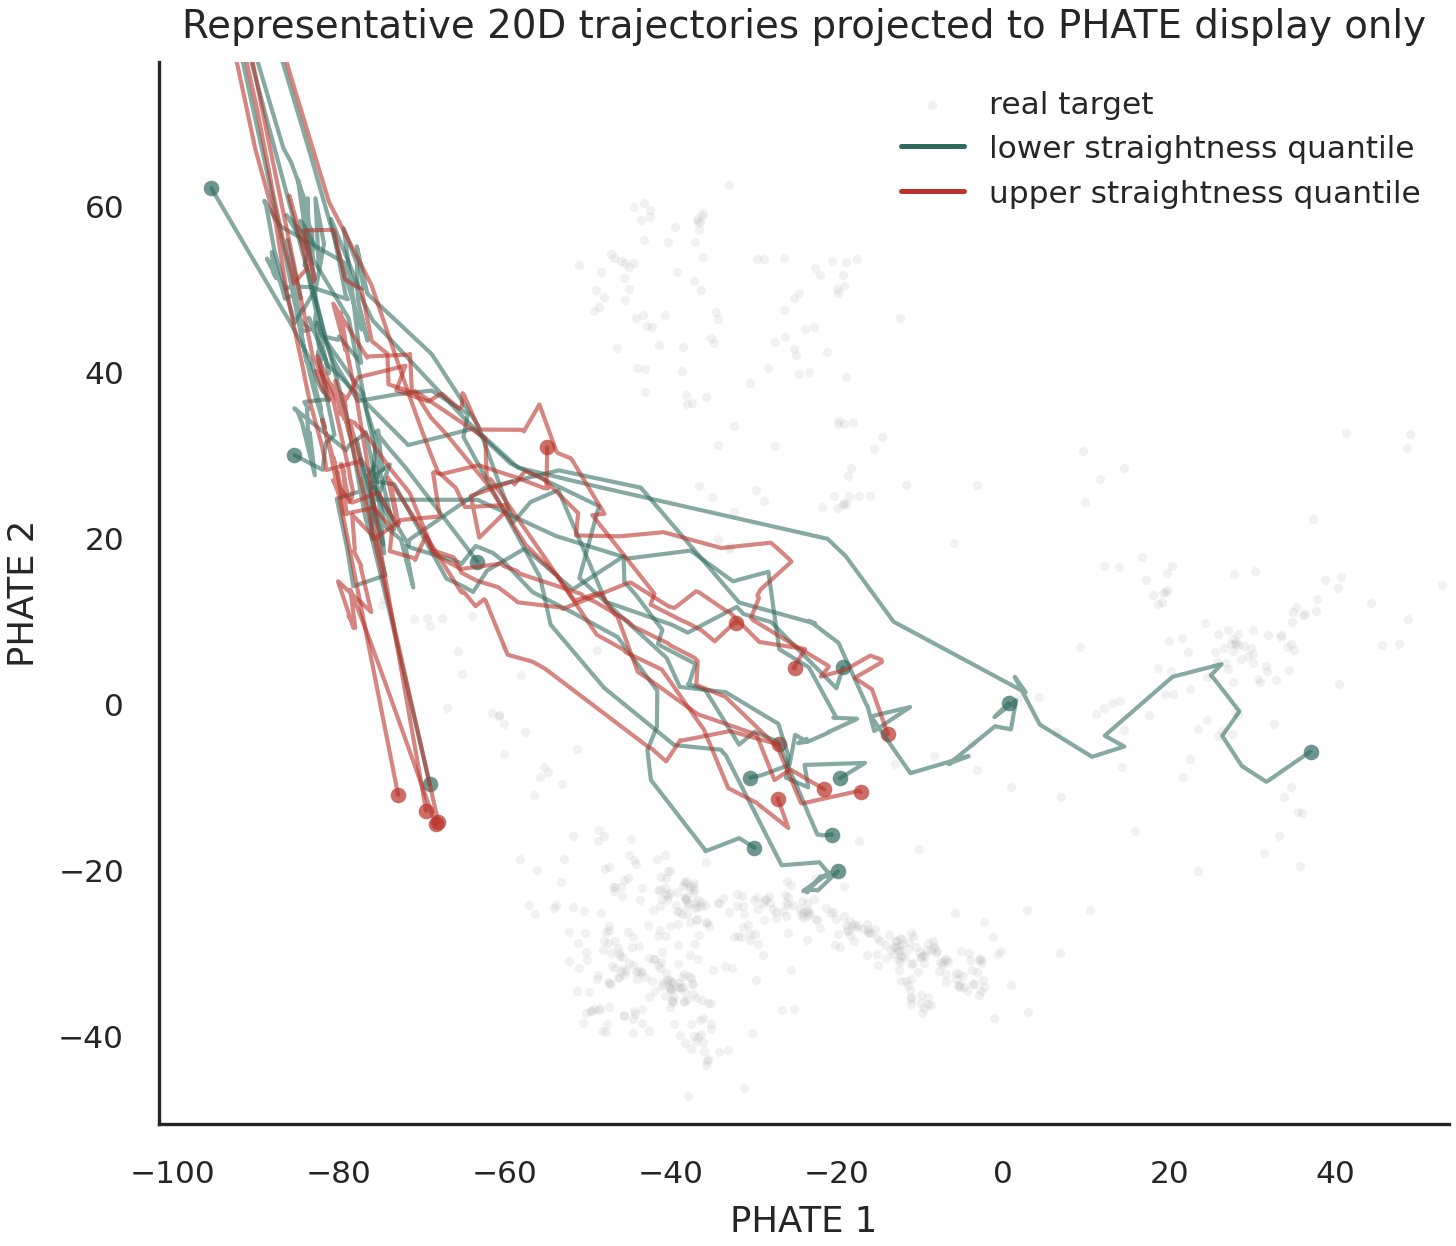

PosixPath('/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/figures/ch03/figE5_representative_trajectories_phate.png')

In [40]:
low_candidates = np.flatnonzero(straight_ratio <= q25)
high_candidates = np.flatnonzero(straight_ratio >= q75)
low_show = low_candidates[subsample_idx(len(low_candidates), min(8, len(low_candidates)), seed=SEED + 610)]
high_show = high_candidates[subsample_idx(len(high_candidates), min(8, len(high_candidates)), seed=SEED + 611)]
fig, ax = plt.subplots(figsize=(5.8, 4.6))
tidx = subsample_idx(len(X_target_phate), 700, seed=SEED + 612)
ax.scatter(X_target_phate[tidx, 0], X_target_phate[tidx, 1], s=5, color="0.70", alpha=0.18, linewidths=0, label="real target")
traj_phate_arrays = []
for j in low_show:
    pts = phate_projector.predict(straight_traj_20d[:, j, :])
    traj_phate_arrays.append(pts)
    ax.plot(pts[:, 0], pts[:, 1], color="#2F6B5E", alpha=0.58, linewidth=1.0)
    ax.scatter(pts[[0, -1], 0], pts[[0, -1], 1], s=14, color="#2F6B5E", alpha=0.70, linewidths=0)
for j in high_show:
    pts = phate_projector.predict(straight_traj_20d[:, j, :])
    traj_phate_arrays.append(pts)
    ax.plot(pts[:, 0], pts[:, 1], color="#B9352B", alpha=0.60, linewidth=1.0)
    ax.scatter(pts[[0, -1], 0], pts[[0, -1], 1], s=14, color="#B9352B", alpha=0.72, linewidths=0)
all_traj_plot = np.vstack(traj_phate_arrays) if traj_phate_arrays else X_target_phate[tidx]
xlim, ylim = robust_limits(X_target_phate[tidx], all_traj_plot, margin=0.10)
format_axis(ax, xlim, ylim, xlabel="PHATE 1", ylabel="PHATE 2", title="Representative 20D trajectories projected to PHATE display only")
ax.plot([], [], color="#2F6B5E", label="lower straightness quantile")
ax.plot([], [], color="#B9352B", label="upper straightness quantile")
ax.legend(frameon=False, loc="best")
straight_traj_path = tracker.save_figure(fig, "figE5_representative_trajectories_phate.png")
tracker.display_saved_figure(straight_traj_path, width=650)


### Claim boundary

Straightness is a numerical trajectory diagnostic in 20D PC space. It is not a lineage certificate and does not validate individual biological paths.


## Paper-ready tables

The export pass keeps the retired-monolith paper table filenames and previews each key table after writing the CSV/TEX/Markdown variants.


In [41]:
solver_paper = ch03.format_solver_diagnostics_paper_table(solver_table)
tracker.save_paper_table(solver_paper, "paper_table03_01_solver_diagnostics")
tracker.display_table(pd.read_csv(TABLE_DIR / "paper_table03_01_solver_diagnostics.csv"), n=8)


,Solver,Steps,NFE,Time (ms),MMD (20D) ↓,Sliced W2 (20D) ↓,Straightness (20D)
0,euler,5,5,82.7,0.0189,0.625,0.069
1,euler,10,10,2.3,0.0154,0.577,0.068
2,euler,20,20,4.4,0.0143,0.529,0.067
3,euler,50,50,9.3,0.0139,0.551,0.066
4,euler,100,100,18.7,0.0137,0.515,0.065
5,midpoint,5,10,2.4,0.0137,0.538,0.064
6,midpoint,10,20,3.9,0.0136,0.511,0.065
7,midpoint,20,40,7.3,0.0136,0.540,0.065


,Solver,Steps,NFE,Time (ms),MMD (20D) ↓,Sliced W2 (20D) ↓,Straightness (20D)
0,euler,5,5,82.7,0.0189,0.625,0.069
1,euler,10,10,2.3,0.0154,0.577,0.068
2,euler,20,20,4.4,0.0143,0.529,0.067
3,euler,50,50,9.3,0.0139,0.551,0.066
4,euler,100,100,18.7,0.0137,0.515,0.065
5,midpoint,5,10,2.4,0.0137,0.538,0.064
6,midpoint,10,20,3.9,0.0136,0.511,0.065
7,midpoint,20,40,7.3,0.0136,0.540,0.065


In [42]:
E1_paper = E1_table.copy()
E1_paper["Method"] = E1_paper["method"]
E1_paper["Objective"] = E1_paper["train_objective"].str.replace("_", " ")
E1_paper["Uses ODE"] = E1_paper["train_uses_ode"].map({True: "yes", False: "no"})
E1_paper["Steps"] = E1_paper["steps"].astype(int)
E1_paper["Batch"] = E1_paper["batch_size"].astype(int)
E1_paper["Time (s)"] = ch03.round_float(E1_paper["wall_time_sec"], 2)
E1_paper["NFE/step"] = ch03.round_float(E1_paper["train_nfe_per_step"], 1)
E1_paper["MMD (20D) ↓"] = ch03.round_float(E1_paper["endpoint_mmd_20d"], 4)
E1_paper["Sliced W2 (20D) ↓"] = ch03.round_float(E1_paper["sliced_w2_20d"], 3)
E1_paper["Mode"] = "QUICK diagnostic" if QUICK_MODE else "full run"
E1_paper = E1_paper[["Method", "Objective", "Uses ODE", "Steps", "Batch", "Time (s)", "NFE/step", "MMD (20D) ↓", "Sliced W2 (20D) ↓", "Mode"]]
tracker.save_paper_table(E1_paper, "paper_tableE1_cfm_vs_cnf_endpoint")
tracker.display_table(E1_paper, n=8)


,Method,Objective,Uses ODE,Steps,Batch,Time (s),NFE/step,MMD (20D) ↓,Sliced W2 (20D) ↓,Mode
0,CFM,local velocity regression 20D,no,80,64,0.20,1.0,0.0346,0.890,QUICK diagnostic
1,CNF-Endpoint,endpoint mse after adjoint ode solve 20D,yes,80,64,3.86,46.0,0.2542,1.493,QUICK diagnostic


,Method,Objective,Uses ODE,Steps,Batch,Time (s),NFE/step,MMD (20D) ↓,Sliced W2 (20D) ↓,Mode
0,CFM,local velocity regression 20D,no,80,64,0.20,1.0,0.0346,0.890,QUICK diagnostic
1,CNF-Endpoint,endpoint mse after adjoint ode solve 20D,yes,80,64,3.86,46.0,0.2542,1.493,QUICK diagnostic


In [43]:
time_paper = time_table.copy()
time_paper["Strategy"] = time_paper["strategy"].map(short_strategy_label)
time_paper["Steps"] = time_paper["steps"].astype(int)
time_paper["Train MSE (20D)"] = ch03.round_float(time_paper["final_train_loss_20d"], 3)
time_paper["Val MSE (20D)"] = ch03.round_float(time_paper["final_val_mse_20d"], 3)
time_paper["MMD (20D) ↓"] = ch03.round_float(time_paper["endpoint_mmd_20d"], 4)
time_paper["Sliced W2 (20D) ↓"] = ch03.round_float(time_paper["sliced_w2_20d"], 3)
time_paper["NFE"] = time_paper["sample_nfe"].astype(int)
time_paper["Time (s)"] = ch03.round_float(time_paper["wall_time_sec"], 2)
time_paper = time_paper[["Strategy", "Steps", "Train MSE (20D)", "Val MSE (20D)", "MMD (20D) ↓", "Sliced W2 (20D) ↓", "NFE", "Time (s)"]]
tracker.save_paper_table(time_paper, "paper_tableE3_time_sampling_ablation")
tracker.display_table(time_paper, n=8)


,Strategy,Steps,Train MSE (20D),Val MSE (20D),MMD (20D) ↓,Sliced W2 (20D) ↓,NFE,Time (s)
0,uniform,350,6.089,5.745,0.0157,0.626,30,0.57
1,logit sigma=.5,350,4.567,5.929,0.0153,0.951,30,0.53
2,logit sigma=1,350,5.240,5.713,0.0135,0.506,30,0.54
3,logit sigma=2,350,5.473,5.707,0.0149,0.562,30,0.48
4,"beta(2,2)",350,4.958,5.753,0.0144,0.615,30,0.51
5,"beta(.5,.5)",350,6.018,5.963,0.0195,0.623,30,0.52
6,cosine,350,5.338,5.969,0.0182,0.685,30,0.50


,Strategy,Steps,Train MSE (20D),Val MSE (20D),MMD (20D) ↓,Sliced W2 (20D) ↓,NFE,Time (s)
0,uniform,350,6.089,5.745,0.0157,0.626,30,0.57
1,logit sigma=.5,350,4.567,5.929,0.0153,0.951,30,0.53
2,logit sigma=1,350,5.240,5.713,0.0135,0.506,30,0.54
3,logit sigma=2,350,5.473,5.707,0.0149,0.562,30,0.48
4,"beta(2,2)",350,4.958,5.753,0.0144,0.615,30,0.51
5,"beta(.5,.5)",350,6.018,5.963,0.0195,0.623,30,0.52
6,cosine,350,5.338,5.969,0.0182,0.685,30,0.50


In [44]:
cap_paper = capacity_table.copy()
cap_paper["Config"] = cap_paper["config"]
cap_paper["Input dim"] = cap_paper["input_dim"].astype(int)
cap_paper["Output dim"] = cap_paper["output_dim"].astype(int)
cap_paper["Hidden"] = cap_paper["hidden_dim"].astype(int)
cap_paper["Layers"] = cap_paper["hidden_layers"].astype(int)
cap_paper["Params"] = cap_paper["n_parameters"].astype(int)
cap_paper["Steps"] = cap_paper["steps"].astype(int)
cap_paper["Train MSE (20D)"] = ch03.round_float(cap_paper["final_train_mse_20d"], 3)
cap_paper["Val MSE (20D)"] = ch03.round_float(cap_paper["final_val_mse_20d"], 3)
cap_paper["MMD (20D) ↓"] = ch03.round_float(cap_paper["endpoint_mmd_20d"], 4)
cap_paper["Sliced W2 (20D) ↓"] = ch03.round_float(cap_paper["sliced_w2_20d"], 3)
cap_paper["Time (s)"] = ch03.round_float(cap_paper["wall_time_sec"], 2)
cap_paper = cap_paper[["Config", "Input dim", "Output dim", "Hidden", "Layers", "Params", "Steps", "Train MSE (20D)", "Val MSE (20D)", "MMD (20D) ↓", "Sliced W2 (20D) ↓", "Time (s)"]]
tracker.save_paper_table(cap_paper, "paper_tableT2_training_hyperparams_capacity")
tracker.display_table(cap_paper, n=8)


,Config,Input dim,Output dim,Hidden,Layers,Params,Steps,Train MSE (20D),Val MSE (20D),MMD (20D) ↓,Sliced W2 (20D) ↓,Time (s)
0,tiny,20,20,64,3,11028,300,5.679,6.645,0.0191,0.592,0.39
1,small,20,20,128,4,54932,300,5.899,6.389,0.0157,0.604,0.44
2,medium,20,20,256,4,208148,300,6.074,5.915,0.0144,0.563,0.43


,Config,Input dim,Output dim,Hidden,Layers,Params,Steps,Train MSE (20D),Val MSE (20D),MMD (20D) ↓,Sliced W2 (20D) ↓,Time (s)
0,tiny,20,20,64,3,11028,300,5.679,6.645,0.0191,0.592,0.39
1,small,20,20,128,4,54932,300,5.899,6.389,0.0157,0.604,0.44
2,medium,20,20,256,4,208148,300,6.074,5.915,0.0144,0.563,0.43


In [45]:
straight_summary = pd.DataFrame([
    {"Metric": "Straightness ratio (20D)", "count": int(straight_table["straightness_ratio_20d"].count()), "mean": round(float(straight_table["straightness_ratio_20d"].mean()), 3), "median": round(float(straight_table["straightness_ratio_20d"].median()), 3), "std": round(float(straight_table["straightness_ratio_20d"].std()), 3), "q10": round(float(straight_table["straightness_ratio_20d"].quantile(0.10)), 3), "q90": round(float(straight_table["straightness_ratio_20d"].quantile(0.90)), 3), "max": round(float(straight_table["straightness_ratio_20d"].max()), 3)},
    {"Metric": "Endpoint distance (20D)", "count": int(straight_table["endpoint_distance_20d"].count()), "mean": round(float(straight_table["endpoint_distance_20d"].mean()), 3), "median": round(float(straight_table["endpoint_distance_20d"].median()), 3), "std": round(float(straight_table["endpoint_distance_20d"].std()), 3), "q10": round(float(straight_table["endpoint_distance_20d"].quantile(0.10)), 3), "q90": round(float(straight_table["endpoint_distance_20d"].quantile(0.90)), 3), "max": round(float(straight_table["endpoint_distance_20d"].max()), 3)},
])
tracker.save_paper_table(straight_summary, "paper_tableE5_trajectory_straightness_summary")
tracker.display_table(straight_summary, n=8)


,Metric,count,mean,median,std,q10,q90,max
0,Straightness ratio (20D),180,1.066,1.046,0.062,1.015,1.132,1.404
1,Endpoint distance (20D),180,11.140,10.702,3.610,6.818,16.233,21.321


,Metric,count,mean,median,std,q10,q90,max
0,Straightness ratio (20D),180,1.066,1.046,0.062,1.015,1.132,1.404
1,Endpoint distance (20D),180,11.140,10.702,3.610,6.818,16.233,21.321


In [46]:
paper_ready_pass_completed = True
figure_quality_notes = {
    "style": "Unified DejaVu Sans paper style, light grids only on metric plots, top/right spines removed.",
    "phate": "PHATE annotations moved to short corner notes; PHATE is display only.",
    "quick_mode": "E1/E2/E3 diagnostics are QUICK_MODE unless rerun with QUICK_MODE=False.",
    "fig03_10": "Single concise title and explicit 20D PC metric label.",
}
print({
    "paper_ready_pass_completed": paper_ready_pass_completed,
    "tracker.paper_ready_png_written": len(tracker.paper_ready_png_written),
    "tracker.paper_ready_pdf_written": len(tracker.paper_ready_pdf_written),
    "tracker.paper_tables_written": len(tracker.paper_tables_written),
})


{'paper_ready_pass_completed': True, 'tracker.paper_ready_png_written': 0, 'tracker.paper_ready_pdf_written': 12, 'tracker.paper_tables_written': 15}


## Chapter 3 Artifact Index

The final index records every Chapter 3 artifact, including toy and main-flow artifacts owned by the previous split notebooks. The concept diagrams are tracked as manual/reference figures because they are not generated by this notebook.


In [47]:
manual_concept_figure_paths = {
    "Fig 3.1": PROJECT_ROOT.parent / "tutorial_figure" / "ch03" / "fig03_01_training_vs_sampling_compute.png",
    "Fig 3.5": PROJECT_ROOT.parent / "tutorial_figure" / "ch03" / "fig03_05_velocity_mlp_architecture.png",
    "Fig 3.6": PROJECT_ROOT.parent / "tutorial_figure" / "ch03" / "fig03_06_minimal_cfm_training_loop.png",
    "Fig 3.11": PROJECT_ROOT.parent / "tutorial_figure" / "ch03" / "fig03_11_cfm_extension_map.png",
}
artifact_rows = [
    {"artifact_id": "Fig toy loss", "artifact_type": "figure", "path": "figures/ch03/fig_toy_loss.png", "owner": "03_1", "source_section": "toy training", "notes": "Toy-only teaching diagnostic"},
    {"artifact_id": "Fig toy evolution", "artifact_type": "figure", "path": "figures/ch03/fig_toy_evolution.png", "owner": "03_1", "source_section": "toy sampling", "notes": "Toy-only teaching diagnostic"},
    {"artifact_id": "Fig 3.2", "artifact_type": "figure", "path": "figures/ch03/fig03_02_conditional_vs_marginal_toy.png", "owner": "03_1", "source_section": "toy conditional versus marginal", "notes": "Teaching concept only"},
    {"artifact_id": "Fig 3.3", "artifact_type": "figure", "path": "figures/ch03/fig03_03_cfm_object_hierarchy_toy.png", "owner": "03_1", "source_section": "toy object hierarchy", "notes": "Teaching concept only"},
    {"artifact_id": "Fig B1", "artifact_type": "figure", "path": "figures/ch03/figB1_eb20d_train_val_loss.png", "owner": "03_2", "source_section": "EB 20D training", "notes": "Train/val CFM MSE"},
    {"artifact_id": "Fig 3.4", "artifact_type": "figure", "path": "figures/ch03/fig03_04_eb_endpoint_pairs_phate.png", "owner": "03_2", "source_section": "EB endpoint pair visualization", "notes": "PHATE display only"},
    {"artifact_id": "Fig 3.8", "artifact_type": "figure", "path": "figures/ch03/fig03_08_eb_population_evolution_phate.png", "owner": "03_2", "source_section": "EB population evolution", "notes": "20D Euler states projected with kNN"},
    {"artifact_id": "Fig 3.9", "artifact_type": "figure", "path": "figures/ch03/fig03_09_euler_step_sensitivity_phate.png", "owner": "03_2", "source_section": "Euler sensitivity", "notes": "PHATE display only; metrics in CSV"},
    {"artifact_id": "Table EB counts", "artifact_type": "table", "path": "tables/ch03/ch03_eb_timepoint_counts.csv", "owner": "03_2", "source_section": "EB data audit", "notes": "Selected timepoint counts"},
    {"artifact_id": "Table EB split", "artifact_type": "table", "path": "tables/ch03/ch03_eb20d_train_val_split.csv", "owner": "03_2", "source_section": "EB train/val split", "notes": "Split sizes"},
    {"artifact_id": "Table EB training", "artifact_type": "table", "path": "tables/ch03/ch03_eb20d_training_log.csv", "owner": "03_2", "source_section": "EB training", "notes": "Optimization history"},
    {"artifact_id": "Table Euler", "artifact_type": "table", "path": "tables/ch03/ch03_euler_step_sensitivity.csv", "owner": "03_2", "source_section": "Euler sensitivity", "notes": "NFE sensitivity metrics"},
]


In [48]:
artifact_rows.extend([
    {"artifact_id": "Fig 3.10", "artifact_type": "figure", "path": "figures/ch03/fig03_10_nfe_vs_endpoint_error.png", "owner": "03_3", "source_section": "solver comparison", "notes": "NFE versus endpoint MMD"},
    {"artifact_id": "Table 3.1", "artifact_type": "table", "path": "tables/ch03/table03_01_solver_diagnostics.csv", "owner": "03_3", "source_section": "solver comparison", "notes": "Solver diagnostics"},
    {"artifact_id": "Fig E1 cost", "artifact_type": "figure", "path": "figures/ch03/figE1_cfm_vs_cnf_endpoint_training_cost.png", "owner": "03_3", "source_section": "CNF endpoint baseline", "notes": "CFM local regression versus adjoint endpoint training"},
    {"artifact_id": "Fig E1 samples", "artifact_type": "figure", "path": "figures/ch03/figE1_cfm_vs_cnf_endpoint_samples_phate.png", "owner": "03_3", "source_section": "CNF endpoint baseline", "notes": "PHATE display only"},
    {"artifact_id": "Table E1", "artifact_type": "table", "path": "tables/ch03/tableE1_cfm_vs_cnf_endpoint.csv", "owner": "03_3", "source_section": "CNF endpoint baseline", "notes": "Training-cost summary"},
    {"artifact_id": "Fig E2 val", "artifact_type": "figure", "path": "figures/ch03/figE2_capacity_val_mse.png", "owner": "03_3", "source_section": "capacity ablation", "notes": "Parameter count versus val MSE"},
    {"artifact_id": "Fig E2 mmd", "artifact_type": "figure", "path": "figures/ch03/figE2_capacity_endpoint_mmd.png", "owner": "03_3", "source_section": "capacity ablation", "notes": "Parameter count versus endpoint MMD"},
    {"artifact_id": "Table T2", "artifact_type": "table", "path": "tables/ch03/tableT2_training_hyperparams_capacity.csv", "owner": "03_3", "source_section": "capacity ablation", "notes": "Capacity hyperparameters and metrics"},
    {"artifact_id": "Fig E3 distributions", "artifact_type": "figure", "path": "figures/ch03/figE3_time_sampling_distributions.png", "owner": "03_3", "source_section": "time sampling", "notes": "Sampled t distributions"},
    {"artifact_id": "Fig E3 val", "artifact_type": "figure", "path": "figures/ch03/figE3_time_sampling_val_mse.png", "owner": "03_3", "source_section": "time sampling", "notes": "Validation MSE curves"},
    {"artifact_id": "Fig E3 mmd", "artifact_type": "figure", "path": "figures/ch03/figE3_time_sampling_endpoint_mmd.png", "owner": "03_3", "source_section": "time sampling", "notes": "Endpoint MMD"},
    {"artifact_id": "Fig E3 bars", "artifact_type": "figure", "path": "figures/ch03/figE3_time_sampling_final_bar.png", "owner": "03_3", "source_section": "time sampling", "notes": "Final MMD and Sliced W2"},
    {"artifact_id": "Table E3", "artifact_type": "table", "path": "tables/ch03/tableE3_time_sampling_ablation.csv", "owner": "03_3", "source_section": "time sampling", "notes": "Time sampling final metrics"},
    {"artifact_id": "Fig E5 hist", "artifact_type": "figure", "path": "figures/ch03/figE5_straightness_hist.png", "owner": "03_3", "source_section": "straightness", "notes": "20D straightness histogram"},
    {"artifact_id": "Fig E5 trajectories", "artifact_type": "figure", "path": "figures/ch03/figE5_representative_trajectories_phate.png", "owner": "03_3", "source_section": "straightness", "notes": "PHATE display only"},
    {"artifact_id": "Fig E5 scatter", "artifact_type": "figure", "path": "figures/ch03/figE5_endpoint_distance_vs_straightness.png", "owner": "03_3", "source_section": "straightness", "notes": "Endpoint distance versus straightness"},
    {"artifact_id": "Table E5", "artifact_type": "table", "path": "tables/ch03/tableE5_trajectory_straightness.csv", "owner": "03_3", "source_section": "straightness", "notes": "Per-trajectory 20D straightness"},
])
for fig_id, fig_path in manual_concept_figure_paths.items():
    artifact_rows.append({"artifact_id": fig_id, "artifact_type": "figure", "path": str(fig_path), "owner": "manual", "source_section": "manual concept diagram", "notes": "Manual/reference concept figure"})


In [49]:
artifact_index = pd.DataFrame(artifact_rows)
artifact_index["exists"] = artifact_index["path"].map(lambda p: Path(p).exists() if Path(p).is_absolute() else (PROJECT_ROOT / p).exists())
artifact_index["status"] = np.where(artifact_index["exists"], "written", "missing")
artifact_index.loc[artifact_index["owner"].eq("manual") & artifact_index["exists"], "status"] = "external_local"
artifact_index.loc[artifact_index["owner"].eq("manual") & ~artifact_index["exists"], "status"] = "external_missing"
main_text_ids = {"Fig 3.2", "Fig 3.3", "Fig 3.4", "Fig 3.8", "Fig 3.9", "Fig 3.10", "Fig B1", "Table 3.1"}
artifact_index["include_in_main_text"] = np.where(artifact_index["artifact_id"].isin(main_text_ids), "yes", "no")
artifact_index["include_in_appendix"] = np.where(artifact_index["artifact_id"].str.contains("E|T2", regex=True), "yes", "no")
tracker.save_csv(artifact_index, "ch03_artifact_index.csv")
artifact_index_written = bool((TABLE_DIR / "ch03_artifact_index.csv").exists())
tracker.display_table(artifact_index, n=40)


,artifact_id,artifact_type,path,owner,source_section,notes,exists,status,include_in_main_text,include_in_appendix
0,Fig toy loss,figure,figures/ch03/fig_toy_loss.png,03_1,toy training,Toy-only teaching diagnostic,True,written,no,no
1,Fig toy evolution,figure,figures/ch03/fig_toy_evolution.png,03_1,toy sampling,Toy-only teaching diagnostic,True,written,no,no
2,Fig 3.2,figure,figures/ch03/fig03_02_conditional_vs_marginal_...,03_1,toy conditional versus marginal,Teaching concept only,True,written,yes,no
3,Fig 3.3,figure,figures/ch03/fig03_03_cfm_object_hierarchy_toy...,03_1,toy object hierarchy,Teaching concept only,True,written,yes,no
4,Fig B1,figure,figures/ch03/figB1_eb20d_train_val_loss.png,03_2,EB 20D training,Train/val CFM MSE,True,written,yes,no
5,Fig 3.4,figure,figures/ch03/fig03_04_eb_endpoint_pairs_phate.png,03_2,EB endpoint pair visualization,PHATE display only,True,written,yes,no
6,Fig 3.8,figure,figures/ch03/fig03_08_eb_population_evolution_...,03_2,EB population evolution,20D Euler states projected with kNN,True,written,yes,no
7,Fig 3.9,figure,figures/ch03/fig03_09_euler_step_sensitivity_p...,03_2,Euler sensitivity,PHATE display only; metrics in CSV,True,written,yes,no
8,Table EB counts,table,tables/ch03/ch03_eb_timepoint_counts.csv,03_2,EB data audit,Selected timepoint counts,True,written,no,yes
9,Table EB split,table,tables/ch03/ch03_eb20d_train_val_split.csv,03_2,EB train/val split,Split sizes,True,written,no,yes


,artifact_id,artifact_type,path,owner,source_section,notes,exists,status,include_in_main_text,include_in_appendix
0,Fig toy loss,figure,figures/ch03/fig_toy_loss.png,03_1,toy training,Toy-only teaching diagnostic,True,written,no,no
1,Fig toy evolution,figure,figures/ch03/fig_toy_evolution.png,03_1,toy sampling,Toy-only teaching diagnostic,True,written,no,no
2,Fig 3.2,figure,figures/ch03/fig03_02_conditional_vs_marginal_...,03_1,toy conditional versus marginal,Teaching concept only,True,written,yes,no
3,Fig 3.3,figure,figures/ch03/fig03_03_cfm_object_hierarchy_toy...,03_1,toy object hierarchy,Teaching concept only,True,written,yes,no
4,Fig B1,figure,figures/ch03/figB1_eb20d_train_val_loss.png,03_2,EB 20D training,Train/val CFM MSE,True,written,yes,no
5,Fig 3.4,figure,figures/ch03/fig03_04_eb_endpoint_pairs_phate.png,03_2,EB endpoint pair visualization,PHATE display only,True,written,yes,no
6,Fig 3.8,figure,figures/ch03/fig03_08_eb_population_evolution_...,03_2,EB population evolution,20D Euler states projected with kNN,True,written,yes,no
7,Fig 3.9,figure,figures/ch03/fig03_09_euler_step_sensitivity_p...,03_2,Euler sensitivity,PHATE display only; metrics in CSV,True,written,yes,no
8,Table EB counts,table,tables/ch03/ch03_eb_timepoint_counts.csv,03_2,EB data audit,Selected timepoint counts,True,written,no,yes
9,Table EB split,table,tables/ch03/ch03_eb20d_train_val_split.csv,03_2,EB train/val split,Split sizes,True,written,no,yes


## Validation Notes and Summary

This summary is the split-aware replacement for the old monolithic Chapter 3 summary. It records ownership, artifact expectations, and conservative claim boundaries.


In [50]:
own_code_figure_paths = [
    "figures/ch03/fig03_10_nfe_vs_endpoint_error.png",
    "figures/ch03/figE1_cfm_vs_cnf_endpoint_training_cost.png",
    "figures/ch03/figE1_cfm_vs_cnf_endpoint_samples_phate.png",
    "figures/ch03/figE3_time_sampling_distributions.png",
    "figures/ch03/figE3_time_sampling_val_mse.png",
    "figures/ch03/figE3_time_sampling_endpoint_mmd.png",
    "figures/ch03/figE3_time_sampling_final_bar.png",
    "figures/ch03/figE2_capacity_val_mse.png",
    "figures/ch03/figE2_capacity_endpoint_mmd.png",
    "figures/ch03/figE5_straightness_hist.png",
    "figures/ch03/figE5_representative_trajectories_phate.png",
    "figures/ch03/figE5_endpoint_distance_vs_straightness.png",
]
own_table_paths = [
    "tables/ch03/table03_01_solver_diagnostics.csv",
    "tables/ch03/tableE1_cfm_vs_cnf_endpoint.csv",
    "tables/ch03/tableE3_time_sampling_ablation.csv",
    "tables/ch03/tableT2_training_hyperparams_capacity.csv",
    "tables/ch03/tableE5_trajectory_straightness.csv",
    "tables/ch03/ch03_artifact_index.csv",
]
paper_table_paths = [
    "tables/ch03/paper_table03_01_solver_diagnostics.csv",
    "tables/ch03/paper_table03_01_solver_diagnostics.tex",
    "tables/ch03/paper_table03_01_solver_diagnostics.md",
    "tables/ch03/paper_tableE1_cfm_vs_cnf_endpoint.csv",
    "tables/ch03/paper_tableE1_cfm_vs_cnf_endpoint.md",
    "tables/ch03/paper_tableE1_cfm_vs_cnf_endpoint.tex",
    "tables/ch03/paper_tableE3_time_sampling_ablation.csv",
    "tables/ch03/paper_tableE3_time_sampling_ablation.md",
    "tables/ch03/paper_tableE3_time_sampling_ablation.tex",
    "tables/ch03/paper_tableT2_training_hyperparams_capacity.csv",
    "tables/ch03/paper_tableT2_training_hyperparams_capacity.md",
    "tables/ch03/paper_tableT2_training_hyperparams_capacity.tex",
    "tables/ch03/paper_tableE5_trajectory_straightness_summary.csv",
    "tables/ch03/paper_tableE5_trajectory_straightness_summary.md",
    "tables/ch03/paper_tableE5_trajectory_straightness_summary.tex",
]


In [51]:
validation_checks = {
    "eb_training_state_dim_is_20": bool(X0_train.shape[1] == 20 and X1_train.shape[1] == 20),
    "phate_state_dim_is_2_for_plots_only": bool(X0_train_phate.shape[1] == 2 and X1_train_phate.shape[1] == 2),
    "main_model_cache_exists": bool(MAIN_MODEL_PATH.exists()),
    "solver_table_exists": bool((TABLE_DIR / "table03_01_solver_diagnostics.csv").exists()),
    "artifact_index_exists": bool((TABLE_DIR / "ch03_artifact_index.csv").exists()),
    "own_code_figures_written": bool(all((PROJECT_ROOT / rel).exists() for rel in own_code_figure_paths)),
    "own_tables_written": bool(all((PROJECT_ROOT / rel).exists() for rel in own_table_paths)),
    "tracker.paper_tables_written": bool(all((PROJECT_ROOT / rel).exists() for rel in paper_table_paths)),
}
claim_boundaries = [
    "Solver comparison is a post-training numerical diagnostic for one trained EB CFM field.",
    "CNF-Endpoint is endpoint-loss adjoint training, not likelihood-based CNF or FFJORD evidence.",
    "Time sampling and capacity ablations are finite-budget diagnostics on the EB endpoint-pair task.",
    "Straightness is a 20D numerical path diagnostic, not an individual lineage certificate.",
]
summary = {
    "quick_mode": QUICK_MODE,
    "smoke_mode": SMOKE_MODE,
    "device": DEVICE,
    "seed": SEED,
    "source_time": source_time,
    "target_time": target_time,
    "split_notebooks": ["03_1_toy_flow_matching_from_scratch.ipynb", "03_2_eb20d_main_flow_matching.ipynb", "03_3_eb20d_baselines_ablations_and_claim_audit.ipynb"],
    "eb_training_space": "20D PC X_cost",
    "eb_visualization_space": "PHATE X_plot only",
    "phate_used_for_training_or_metrics": False,
    "toy_used_for_eb_claims": False,
    "cnf_endpoint_completed": bool(globals().get("cnf_endpoint_completed", False)),
    "time_sampling_completed": bool(globals().get("time_sampling_completed", False)),
    "capacity_ablation_completed": bool(globals().get("capacity_ablation_completed", False)),
    "straightness_completed": bool(globals().get("straightness_completed", False)),
    "artifact_index_written": bool(globals().get("artifact_index_written", False)),
    "paper_ready_pass_completed": bool(globals().get("paper_ready_pass_completed", False)),
    "known_limitations": ["QUICK_MODE diagnostic results need full rerun before final submission.", "PHATE display uses kNN projection for generated samples.", "CNF-Endpoint is endpoint-loss adjoint diagnostic, not FFJORD likelihood."],
    "claim_boundaries": claim_boundaries,
    "expected_code_figures": own_code_figure_paths,
    "expected_tables": own_table_paths,
    "expected_paper_tables": paper_table_paths,
    "skipped_items": ch03.normalize_skipped_items(skipped_items),
    "validation_checks": validation_checks,
}
summary_path = tracker.save_run_json(summary, "ch03_flow_matching_from_scratch_run_summary.json")
print(json.dumps(ch03.json_ready(summary), indent=2))


{
  "quick_mode": true,
  "smoke_mode": false,
  "device": "cuda",
  "seed": 42,
  "source_time": "0",
  "target_time": "1",
  "split_notebooks": [
    "03_1_toy_flow_matching_from_scratch.ipynb",
    "03_2_eb20d_main_flow_matching.ipynb",
    "03_3_eb20d_baselines_ablations_and_claim_audit.ipynb"
  ],
  "eb_training_space": "20D PC X_cost",
  "eb_visualization_space": "PHATE X_plot only",
  "phate_used_for_training_or_metrics": false,
  "toy_used_for_eb_claims": false,
  "cnf_endpoint_completed": true,
  "time_sampling_completed": true,
  "capacity_ablation_completed": true,
  "straightness_completed": true,
  "artifact_index_written": true,
  "paper_ready_pass_completed": true,
  "known_limitations": [
    "QUICK_MODE diagnostic results need full rerun before final submission.",
    "PHATE display uses kNN projection for generated samples.",
    "CNF-Endpoint is endpoint-loss adjoint diagnostic, not FFJORD likelihood."
  ],
  "claim_boundaries": [
    "Solver comparison is a post-tra

## Artifact audit

This notebook owns the solver/baseline/ablation/straightness artifacts plus the all-Chapter-3 audit files. The manifest cell fails loudly if any expected figure, table, or output is missing or empty.


In [52]:
expected_figures = [PROJECT_ROOT / rel for rel in own_code_figure_paths]
expected_tables = [PROJECT_ROOT / rel for rel in own_table_paths + paper_table_paths]
artifact_manifest_path = OUT_DIR / "artifact_manifest_03_3_eb20d_baselines_ablations_and_claim_audit.csv"
expected_outputs = [OUT_DIR / "ch03_flow_matching_from_scratch_run_summary.json", artifact_manifest_path]

artifact_manifest = ch03.write_required_artifact_manifest(
    artifact_manifest_path,
    expected_figures=expected_figures,
    expected_tables=expected_tables,
    expected_outputs=expected_outputs,
)
tracker.display_table(artifact_manifest, n=40)


,kind,path,exists,bytes
0,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,118006
1,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,91985
2,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,160502
3,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,212811
4,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,150122
5,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,118393
6,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,141130
7,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,93082
8,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,84451
9,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,67179


,kind,path,exists,bytes
0,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,118006
1,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,91985
2,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,160502
3,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,212811
4,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,150122
5,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,118393
6,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,141130
7,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,93082
8,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,84451
9,figure,/import/home4/xmabs/flow_matching_for_dynamic_...,True,67179
